# Lab 02: Data Mining and Visualization
# Group: 02
23127026 - Nguyen Do Bao  
23127118 - Le Nguyen Thao  
23127144 - Dinh Dai Vu  
23127427 - Vu Hoang Minh  
23127447 - Nguyen Thanh Owen  

# 1. Basic Data Analysis

## 1.1 Dataset Overview
The dataset utilized in this project is extracted from the **World Development Indicators (WDI)** by the World Bank. It provides a comprehensive collection of indicators regarding economic, social, and environmental development. This specific dataset focuses on **11 Southeast Asian countries** spanning a 20-year period from 2006 to 2025. It serves as the foundation for exploring trends and relationships across five key domains: Macroeconomics, Health, Education, Energy, and Demographics.

## 1.2 Data Structure Description
Before any manipulation, we will load the dataset to examine its initial structure, including the number of records and available fields. The original data is expected to be in a "wide" format, where time-series data is spread across multiple year-columns.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
# Load the dataset
df = pd.read_csv('data/data.csv')

# Display basic structure information
print(f"Total records (rows): {df.shape[0]}")
print(f"Total fields (columns): {df.shape[1]}")

print("\n--- Column Information ---")
df.info()

print("\n--- First 5 Records ---")
display(df)

Total records (rows): 418
Total fields (columns): 24

--- Column Information ---
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Country Name   418 non-null    str  
 1   Country Code   418 non-null    str  
 2   Series Name    418 non-null    str  
 3   Series Code    418 non-null    str  
 4   2006 [YR2006]  418 non-null    str  
 5   2007 [YR2007]  418 non-null    str  
 6   2008 [YR2008]  418 non-null    str  
 7   2009 [YR2009]  418 non-null    str  
 8   2010 [YR2010]  418 non-null    str  
 9   2011 [YR2011]  418 non-null    str  
 10  2012 [YR2012]  418 non-null    str  
 11  2013 [YR2013]  418 non-null    str  
 12  2014 [YR2014]  418 non-null    str  
 13  2015 [YR2015]  418 non-null    str  
 14  2016 [YR2016]  418 non-null    str  
 15  2017 [YR2017]  418 non-null    str  
 16  2018 [YR2018]  418 non-null    str  
 17  2019 [YR2019]  418 non

,Country Name,Country Code,Series Name,Series Code,2006 [YR2006],2007 [YR2007],2008 [YR2008],2009 [YR2009],2010 [YR2010],2011 [YR2011],...,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,Viet Nam,VNM,GDP growth (annual %),NY.GDP.MKTP.KD.ZG,6.977954811,7.129504486,5.661771209,5.39789754,6.423244822,6.413168897,...,6.690008927,6.940190374,7.465006856,7.359262701,2.865413209,2.553728526,8.537500468,5.065023915,7.091187466,..
1,Viet Nam,VNM,GDP (current US$),NY.GDP.MKTP.CD,66371664817,77414425532,99130304099,1.06015E+11,1.47201E+11,1.72595E+11,...,2.57096E+11,2.81354E+11,3.10106E+11,3.34365E+11,3.46616E+11,3.66475E+11,4.13445E+11,4.33858E+11,4.76388E+11,..
2,Viet Nam,VNM,Trade (% of GDP),NE.TRD.GNFS.ZS,138.3136219,154.605384,154.3174796,134.7063177,113.9776875,125.2605779,...,145.409508,160.9800837,164.6639368,164.704215,163.2458628,186.6758328,183.1536191,164.8180713,173.8620248,..
3,Viet Nam,VNM,Exports of goods and services (% of GDP),NE.EXP.GNFS.ZS,67.71681433,70.5178746,70.33669194,62.60888407,54.17584597,61.18015572,...,74.10728626,81.76252184,84.42345608,85.15758741,84.38159801,93.85020713,93.42012904,86.46741924,90.15422105,..
4,Viet Nam,VNM,Imports of goods and services (% of GDP),NE.IMP.GNFS.ZS,70.59680754,84.08750939,83.98078769,72.09743366,59.80184157,64.08042222,...,71.30222172,79.21756182,80.24048069,79.54662762,78.86426481,92.82562571,89.7334901,78.35065203,83.70780374,..
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,Timor-Leste,TLS,Poverty headcount ratio at national poverty li...,SI.POV.NAHC,..,50.4,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
414,Timor-Leste,TLS,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,3.936162599,10.30090202,9.064236219,0.669681186,6.765976802,13.49984024,...,-1.338538762,0.557215537,2.63647201,0.95881274,0.495499215,3.697920947,7.005309454,8.420351033,2.06284153,..
415,Timor-Leste,TLS,Income share held by highest 10%,SI.DST.10TH.10,..,22.9,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
416,Timor-Leste,TLS,Income share held by lowest 10%,SI.DST.FRST.10,..,4.1,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..


## 1.3 Data Preprocessing
The initial exploration reveals that the dataset requires significant restructuring and cleaning to be suitable for visualization and statistical analysis. We will perform the following preprocessing steps:

1. **Handle Missing Values:** The WDI dataset uses the `..` string to denote missing data. We will convert these to standard `NaN` values.
2. **Reshape Data (Wide to Long):** We will melt the year columns (e.g., `2006 [YR2006]`) into a single `Year` column and a corresponding `Value` column.
3. **Standardize the 'Year' Column:** Extract the 4-digit numeric year and convert its data type to integer.
4. **Data Type Conversion:** Ensure the `Value` column is cast to a numerical format (float).
5. **Restructure (Pivot):** Pivot the `Series Name` into separate columns. This crucial step converts our indicators into distinct variables, allowing for cross-indicator analysis and correlation.

In [41]:
# 1. Replace '..' with NaN
df_cleaned = df.replace('..', np.nan)

# 2. Melt data: transform year columns into a single 'Year' column
id_vars = ['Country Name', 'Country Code', 'Series Name', 'Series Code']
year_cols = [col for col in df_cleaned.columns if 'YR' in col]

df_long = pd.melt(df_cleaned, id_vars=id_vars, value_vars=year_cols, 
                  var_name='Year_Raw', value_name='Value')

# 3. Standardize 'Year' (Extract 4 digits using regex)
df_long['Year'] = df_long['Year_Raw'].str.extract(r'(\d{4})').astype(int)
df_long = df_long.drop(columns=['Year_Raw'])

# 4. Convert 'Value' to float
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

# 5. Pivot: Indicators become columns
df_final = df_long.pivot_table(index=['Country Name', 'Country Code', 'Year'], 
                               columns='Series Name', 
                               values='Value').reset_index()

df_final.columns.name = None # Clean up index name

print(f"Cleaned dataset shape: {df_final.shape[0]} rows, {df_final.shape[1]} columns")
display(df_final.head())

Cleaned dataset shape: 211 rows, 41 columns


,Country Name,Country Code,Year,"Adolescent fertility rate (births per 1,000 women ages 15-19)","Agriculture, forestry, and fishing, value added (% of GDP)",Carbon intensity of GDP (kg CO2e per 2021 PPP $ of GDP),Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP),Coal rents (% of GDP),"Contraceptive prevalence, any method (% of married women ages 15-49)",Current health expenditure (% of GDP),...,"Population, total",Poverty headcount ratio at national poverty lines (% of population),"Primary completion rate, total (% of relevant age group)",Research and development expenditure (% of GDP),"School enrollment, tertiary (% gross)","Services, value added (% of GDP)",Total natural resources rents (% of GDP),Trade (% of GDP),Urban population (% of total population),"Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)"
0,Brunei Darussalam,BRN,2006,16.471,0.754743,0.231064,0.618005,0.0,NaN,1.907252,...,364663.0,NaN,115.946068,NaN,15.206880,26.208741,37.406588,81.570955,74.014830,151.530781
1,Brunei Darussalam,BRN,2007,16.392,0.726343,0.228086,0.610041,0.0,NaN,1.941454,...,370873.0,NaN,118.802338,NaN,15.484700,27.768295,33.599157,81.011415,74.434486,145.827733
2,Brunei Darussalam,BRN,2008,15.882,0.692166,0.258323,0.690911,0.0,NaN,1.876120,...,377793.0,NaN,115.731392,NaN,15.738510,24.765496,31.974492,89.745425,74.792941,140.139415
3,Brunei Darussalam,BRN,2009,15.572,0.979918,0.237108,0.634172,0.0,NaN,2.393066,...,384952.0,NaN,110.637649,NaN,16.565849,33.614346,23.552104,90.287088,75.071297,137.476410
4,Brunei Darussalam,BRN,2010,15.228,0.733350,0.212327,0.567892,0.0,NaN,2.278261,...,392332.0,NaN,106.822058,NaN,15.333156,32.503044,26.715244,95.371546,75.250656,141.245140


## **1.4. Missing Value Strategy**

Due to inherent reporting lags in the World Bank's WDI dataset, missing values (NaN) are highly prevalent in recent years. To preserve the absolute accuracy of the macroeconomic picture, this project applies a flexible and targeted handling strategy rather than mechanical imputation:

1. **No Cross-Sectional Imputation:** We strictly avoid replacing a missing indicator (e.g., GDP or Inflation) for a specific country with the ASEAN regional average, as this would completely distort that nation's true economic reality.
2. **Within-Country Temporal Interpolation:** For time-series charts, missing intermediate years are smoothed using linear interpolation. Crucially, this calculation is *based solely on the specific country's own historical data* to maintain chronological continuity without fabricating absolute magnitudes.
3. **Targeted Subset Filtering:** Global row deletion is avoided to prevent massive data loss. Instead, missing values are excluded on a *per-visual basis*, dropping only the rows that lack the specific variables currently being analyzed. This preserves maximum data availability for other charts.
4. **Robust Regional Aggregation:** When calculating the "ASEAN Average", the algorithm automatically bypasses empty cells. The regional baseline is computed based strictly on the countries that actually reported data for that year, preventing the average from being artificially skewed downward.

## 1.5 Basic Statistical Analysis
With the data cleaned and reshaped into a standard format (where each row represents a specific country in a specific year, and columns represent indicators), we can perform basic statistical analysis. 

This step provides a summary of the central tendency, dispersion, and shape of the dataset's distribution, helping us identify potential outliers or data gaps before creating visualizations.

In [42]:
# Select only numerical columns for statistical analysis
numeric_cols = df_final.select_dtypes(include=[np.number])
numeric_cols = numeric_cols.drop(columns=['Year']) # Exclude Year from stats

# Calculate descriptive statistics
stats_summary = numeric_cols.describe().T

print("--- Descriptive Statistics for Indicators ---")
display(stats_summary)

# Check the distribution of remaining missing values
print("\n--- Missing Values Count per Indicator ---")
missing_counts = numeric_cols.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)
print(missing_counts)

--- Descriptive Statistics for Indicators ---


,count,mean,std,min,25%,50%,75%,max
"Adolescent fertility rate (births per 1,000 women ages 15-19)",198.0,3.647104e+01,2.261397e+01,2.160000e+00,1.531400e+01,3.518150e+01,4.911150e+01,9.061100e+01
"Agriculture, forestry, and fishing, value added (% of GDP)",209.0,1.355934e+01,9.157907e+00,2.597732e-02,8.670181e+00,1.309581e+01,1.786818e+01,4.391896e+01
Carbon intensity of GDP (kg CO2e per 2021 PPP $ of GDP),209.0,1.759477e-01,8.255977e-02,4.473292e-02,1.015457e-01,1.749019e-01,2.310637e-01,4.011639e-01
Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP),209.0,5.497173e-01,2.640039e-01,1.432782e-01,3.311776e-01,5.616245e-01,7.161993e-01,1.267931e+00
Coal rents (% of GDP),158.0,2.674780e-01,5.851641e-01,0.000000e+00,0.000000e+00,2.915643e-02,1.774320e-01,3.716279e+00
"Contraceptive prevalence, any method (% of married women ages 15-49)",54.0,6.103558e+01,1.455409e+01,1.980000e+01,5.242500e+01,6.080000e+01,7.572738e+01,7.960000e+01
Current health expenditure (% of GDP),198.0,3.951195e+00,1.443721e+00,1.326516e+00,2.885015e+00,3.852527e+00,4.626149e+00,9.597795e+00
Energy use (kg of oil equivalent per capita),175.0,2.140507e+03,2.587536e+03,6.041387e+01,4.382741e+02,7.541303e+02,2.692873e+03,9.699300e+03
Exports of goods and services (% of GDP),182.0,6.509087e+01,4.941851e+01,2.409013e+00,2.961629e+01,6.004118e+01,7.140321e+01,2.289938e+02
"Fertility rate, total (births per woman)",198.0,2.313874e+00,8.219617e-01,9.700000e-01,1.880250e+00,2.205500e+00,2.724750e+00,5.474000e+00



--- Missing Values Count per Indicator ---
Contraceptive prevalence, any method (% of married women ages 15-49)                                157
Income share held by highest 10%                                                                    144
Income share held by lowest 10%                                                                     144
Research and development expenditure (% of GDP)                                                     142
Poverty headcount ratio at national poverty lines (% of population)                                 139
Primary completion rate, total (% of relevant age group)                                             55
Coal rents (% of GDP)                                                                                53
High-technology exports (% of manufactured exports)                                                  53
School enrollment, tertiary (% gross)                                                                50
Total natural resour

# 2. Define Objectives and Select Data Fields

In this section, we define 15 specific analysis objectives. For each objective, we explicitly state the selected WDI metrics, explain their meanings, justify their selection, and examine the underlying relationships between these fields.


## 2.1 Macroeconomics & Trade

**Question 1: How did global crisis shocks (2008, 2020-2021) impact Vietnam's economic scale and growth velocity compared to the ASEAN regional average?**
* **Objective:** To evaluate Vietnam's economic resilience by benchmarking both its absolute expansion (GDP scale) and its relative momentum (Growth rate) against the regional standard during major downturns.
* **Metrics & Meaning:** 
    * `GDP (current US$)`: Represents the total economic **scale**. Measuring this against the ASEAN average reveals if Vietnam is closing the gap with its neighbors.
    * `GDP growth (annual %)`: Represents the economic **velocity**. This shows how quickly the economy reacts to or recovers from external shocks.
* **Rationale & Relationships:** These two metrics provide a holistic view of economic health. A high growth rate (velocity) is the engine that drives the increase in total GDP (scale). By comparing both against the ASEAN average, we can determine if Vietnam's resilience is an isolated success or part of a broader regional trend.

**Question 2: How does Vietnam's trade openness and structural reliance on imports/exports compare to the ASEAN regional average over the last 20 years?**
* **Objective:** Evaluate Vietnam's internal structural trade balance (exports vs. imports) and benchmark its overall economic openness against its regional peers.
* **Metrics & Meaning:** 
  * `Trade (% of GDP)`: The sum of exports and imports measured as a share of the total economy. This serves as the ultimate benchmark for regional economic openness.
  * `Exports of goods and services (% of GDP)` & `Imports of goods and services (% of GDP)`: The individual inflow and outflow components of trade, visualizing the internal trade structure.
* **Rationale & Relationships:** By decomposing Vietnam's total trade into its structural components (Exports and Imports), we can examine the internal relationship of its economy to see if it is transitioning to an export-driven model. By overlaying the **ASEAN Average Total Trade** as a benchmark, we can contextualize this data to instantly determine if Vietnam is more aggressively integrated into the global supply chain than a typical neighboring country.

**Question 3: How has FDI driven the structural transformation of Vietnam’s High-Tech sector?**

* **Objective:** To analyze the internal chronological correlation between foreign capital absorption and the technological maturity of Vietnam's manufacturing exports.
* **Metrics & Meaning:** 
  * `Foreign direct investment, net inflows (% of GDP)`: Measures the intensity of foreign capital entering the domestic economy relative to its size.
  * `High-technology exports (% of manufactured exports)`: Represents the share of products with high R&D intensity (e.g., electronics, computers, pharmaceuticals) within the manufacturing sector.
* **Rationale & Relationships:** We hypothesize that FDI acts as a primary catalyst for technology transfer. By isolating Vietnam’s trajectory, we can identify specific periods of **"leapfrogging."** A move toward the **top-right** of the matrix indicates a successful transition where FDI effectively fuels a high-tech export boom. This chart proves whether Vietnam is merely assembling low-value goods or successfully climbing the global value chain.


## 2.2 Health & Public Health

**Question 1: How has the historical trend of health expenditure driven long-term improvements in Vietnam's public health outcomes?**

* **Objective:** To evaluate the long-term efficiency and "Return on Investment" (ROI) of national healthcare spending over a two-decade period.
* **Metrics & Meaning:** 
  * `Current health expenditure (% of GDP)`: The financial *Input*, representing the share of the economy dedicated to healthcare infrastructure and services.
  * `Life expectancy at birth (years)` & `Mortality rate, under-5 (per 1,000)`: The core *Outputs*, representing the ultimate goals of public health—longevity and infant survival.
* **Chart Selection & Rationale:** A **Dual-Axis Combo Chart (Time-Series)**. To truly understand healthcare efficiency, a single-year snapshot is insufficient because health investments have a delayed impact. By plotting 'Year' on the primary X-axis, we track the chronological evolution. Health Expenditure (the Input) is visualized as background bars, while Life Expectancy and Mortality Rates (the Outputs) are overlaid as solid lines on secondary Y-axes. This configuration clearly demonstrates whether sustained financial commitment over the years has successfully translated into a steady upward trend in longevity and a downward trend in child mortality.

**Question 2: How strong is the inverse correlation between immunization coverage and child mortality rates?**
* **Objective:** Mathematically demonstrate the public health value of vaccination programs.
* **Metrics & Meaning:** 
  * `Immunization, DPT (% of children ages 12-23 months)`: The percentage of children receiving the Diphtheria, Pertussis, and Tetanus vaccine.
  * `Mortality rate, infant (per 1,000 live births)`: The number of infants dying before reaching one year of age.
* **Rationale & Relationships:** These metrics were chosen to visualize a strong **inverse correlation**. We expect that as the rate of immunization (preventative measure) goes up, the infant mortality rate (negative outcome) must go down.

**Question 3: How have adolescent and total fertility rates shifted as contraceptive prevalence increases?**
* **Objective:** Analyze the impact of family planning access on demographics.
* **Metrics & Meaning:** 
  * `Contraceptive prevalence, any method (% of married women)`: The usage rate of family planning methods.
  * `Adolescent fertility rate` & `Fertility rate, total`: The number of births per woman (specifically for teens and the general population).
* **Rationale & Relationships:** This looks at a **causal socio-medical relationship**. Access to contraceptives is the independent variable, and fertility rates are the dependent variables. We selected these to see how modern family planning mitigates early and excessive childbearing.


## 2.3 Education & Innovation

**Question 1: Did the boom in internet/mobile coverage coincide with an increase in school enrollment rates?**
* **Objective:** Assess if digital infrastructure acts as an enabler for educational access.
* **Metrics & Meaning:** 
  * `Mobile/Broadband subscriptions (per 100 people)`: Indicators of a country's digital connectivity and infrastructure.
  * `School enrollment, tertiary (% gross)`: The ratio of total enrollment in higher education.
* **Rationale & Relationships:** We are examining an **enabler-outcome relationship**. Digital connectivity provides access to information and e-learning. We selected these metrics to see if the technological boom historically aligns with a surge in higher education pursuit.

**Question 2: How does Vietnam's R&D investment and subsequent service sector growth benchmark against the ASEAN average during the 2011-2019 transition period?**

* **Objective:** To evaluate the structural economic shift of Vietnam by comparing its innovation inputs (R&D) and macroeconomic outputs (Services) directly against regional peers.
* **Metrics & Meaning:** 
  * `Research and development expenditure (% of GDP)`: The **Independent Variable (Catalyst)**. Represents the financial commitment to innovation, technology, and systematic knowledge creation.
  * `Services, value added (% of GDP)`: The **Dependent Variable (Outcome)**. The economic output of the service industry, signaling a nation's transition from basic manufacturing to a high-value, modern economy.
* **Rationale & Relationships:** We are testing a **macroeconomic causality and capability gap**. High R&D historically transforms an economy into a service-oriented one. By benchmarking against the ASEAN average over a critical 8-year timeframe, we can verify if a gap in innovation funding directly correlates with a gap in service sector value-add, highlighting the risk of the "Middle-Income Trap."

**Question 3: Is Gross National Income (GNI) a prerequisite for ensuring high primary education completion rates?**
* **Objective:** To measure whether national wealth disparities dictate educational outcomes or if policy prioritization can override economic limitations.
* **Metrics & Meaning:** 
    * `Total GNI, Atlas method (current US$)`: Represented by **Bubble Size**. It indicates the absolute economic "weight class" of the nation.
    * `Primary completion rate, total (% of relevant age group)`: The **Outcome Variable (Y-axis)**. Values >100% indicate high inclusivity (including over-aged students).
    * `Year`: The **Timeline (X-axis)**. Essential for tracking the "velocity" of development.
* **Rationale & Relationships:** This explores the **Wealth-Education Efficiency**. By mapping the trajectory of Vietnam against the ASEAN average, we can determine if basic education is a "luxury" reserved for wealthy nations or if mid-sized economies can achieve elite results through strategic investment.


## 2.4 Energy & Environmental Ecology

**Question 1: Is the rising energy demand in Viet Nam and ASEAN driving their economies into a high-carbon "Red Zone"?**
* **Objective:** To evaluate the environmental cost of economic expansion by mapping the relationship between energy consumption and carbon intensity, and to determine if Viet Nam's growth model is crossing critical pollution thresholds compared to the regional baseline.
* **Metrics & Meaning:** 
  * `Energy Use (kg of oil eq. per capita):` The horizontal axis representing the absolute scale of resource demand required to fuel the economy.
  * `Carbon Intensity of GDP:` The vertical axis representing the environmental "cleanliness" or inefficiency of that energy use (pollution generated per unit of economic output).
* **Rationale:** Rather than merely looking at a linear trend, this analysis acts as a "Health Check" for sustainable development. We aim to categorize the economic models into distinct zones to see if higher energy consumption is strictly locking these nations into a dirty, fossil-fuel-dependent trap.

**Question 2: Does a high economic reliance on coal extraction drive forest depletion when compared to regional trends?**
* **Objective:** To conduct a direct, year-by-year comparative analysis of coal extraction profits and forest conservation, identifying if Viet Nam’s ecological trajectory deviates from the ASEAN regional baseline.
* **Metrics & Meaning:** 
  * **Coal Rents (% of GDP):** Represents the economic "dependency" on coal extraction. High values indicate significant industrial pressure on natural landscapes.
  * **Forest Area (% of land area):** Represents the "Ecological Health" and the success of national conservation policies.
* **Rationale:** Coal mining is traditionally viewed as a primary driver of deforestation. By placing Viet Nam and ASEAN on the same timeline, we can observe if Viet Nam has successfully "decoupled" its forest growth from its extractive industrial needs.

**Question 3: How does freshwater productivity change under the pressure of population growth and agricultural expansion?**
* **Objective:** To monitor the individual historical trends of economic water efficiency and agricultural dependency to identify the "inflection points" of modernization..
* **Metrics & Meaning:** 
  * `Water productivity, total`: GDP produced per cubic meter of total freshwater withdrawal (The Efficiency Output).
  * `Agriculture, value added (% of GDP)`: The share of the economy tied to water-intensive farming (The Structural Driver).
* **Rationale & Relationships:** By separating these metrics into two parallel timelines, we can pinpoint exactly when Viet Nam’s rapid industrialization began to trigger significant gains in water efficiency compared to the regional average.

## 2.5 Population, Urbanization & Social Security

**Question 1: How does rapid urbanization impact national efforts to eradicate poverty?**
* **Objective:** To evaluate the effectiveness of urbanization as an "engine" for social welfare by measuring the structural shift in population distribution and poverty rates from 2006 to 2022.
* **Metrics & Meaning:** 
  * **Urban population (% of total):** Represents the pace of modernization and spatial economic restructuring (The Driver).
  * **Poverty headcount ratio at national poverty lines (% of population):** Represents the success of social welfare policies (The Outcome).
* **Rationale & Relationships:** Urbanization typically provides better access to high-productivity industrial and service jobs, as well as superior infrastructure. This analysis aims to verify whether the wave of rural-to-urban migration in Viet Nam has genuinely translated into a lever for raising living standards compared to the ASEAN average.

**Question 2: How does Viet Nam's macroeconomic stability (consumer inflation) compare to the regional ASEAN average?**
* **Objective:** To benchmark Viet Nam's inflation volatility against the ASEAN region, identifying historical economic shocks and evaluating the country's long-term stabilization efforts.
* **Metrics & Meaning:** 
  * **Inflation, consumer prices (annual %):** The rate at which the general level of prices for goods and services is rising. It is the primary indicator of macroeconomic health and purchasing power.
* **Rationale:** Inflation directly impacts the cost of living and the effectiveness of social security. By comparing Viet Nam to the ASEAN average, we can determine whether Viet Nam's historical economic turbulence was a localized issue or part of a broader regional trend. Furthermore, it highlights how successfully the country has integrated into regional stability in recent years.

**Question 3: How crucial are personal remittances to the economies of labor-exporting countries?**
* **Objective:** To evaluate the economic dependency on foreign remittances and identify the absolute financial scale of these inflows across ASEAN nations.
* **Metrics & Meaning:** 
    * `Personal remittances, received (% of GDP)`: Measures the structural importance of foreign income to the national economy.
    * `GDP (current US$)`: Represents the total economic size of the country.
    * `Total Remittance Volume (Calculated)`: The actual cash amount in Billion USD ($GDP \times \% \text{Remittances}$).
* **Rationale:** This evaluates a **dependency relationship**. By analyzing both the percentage of GDP and the absolute dollar amount, we can distinguish between countries that are large but independent and those that structurally rely on foreign labor markets.

# 3. Data Visualization

In this combined section, we execute the visualizations for our defined objectives, strictly utilizing `matplotlib` and `seaborn`. For each visualization, we apply a **What, Why, How** framework to justify our chart selection, followed by an in-depth analysis of the visual results and concrete conclusions.

---

## 3.1 Macroeconomics & Trade

### *Objective 1: Impact of crisis shocks on Vietnam's economic scale and growth trajectory vs. ASEAN average.**

**Chart Selection & Rationale:**
* **What:** Side-by-side subplots consisting of a **Grouped Bar Chart** (for GDP Scale) and a **Line Chart** (for GDP Growth).
* **Why:** To avoid cognitive overload and ensure maximum clarity, we separate "Scale" from "Velocity." 
    * The **Grouped Bar Chart** (Left) allows for a direct, year-by-year comparison of Vietnam's total economy size against the "typical" ASEAN economy. 
    * The **Line Chart** (Right) highlights the volatility and resilience of growth rates. 
* **How:** Both charts use the same X-axis (Year) and synchronized shaded areas (`plt.axvspan`) for the 2008 and 2020 crises. This consistent visual framework allows the audience to observe how a dip in growth velocity on the right chart directly correlates with the stagnation or expansion of the economic scale on the left chart.

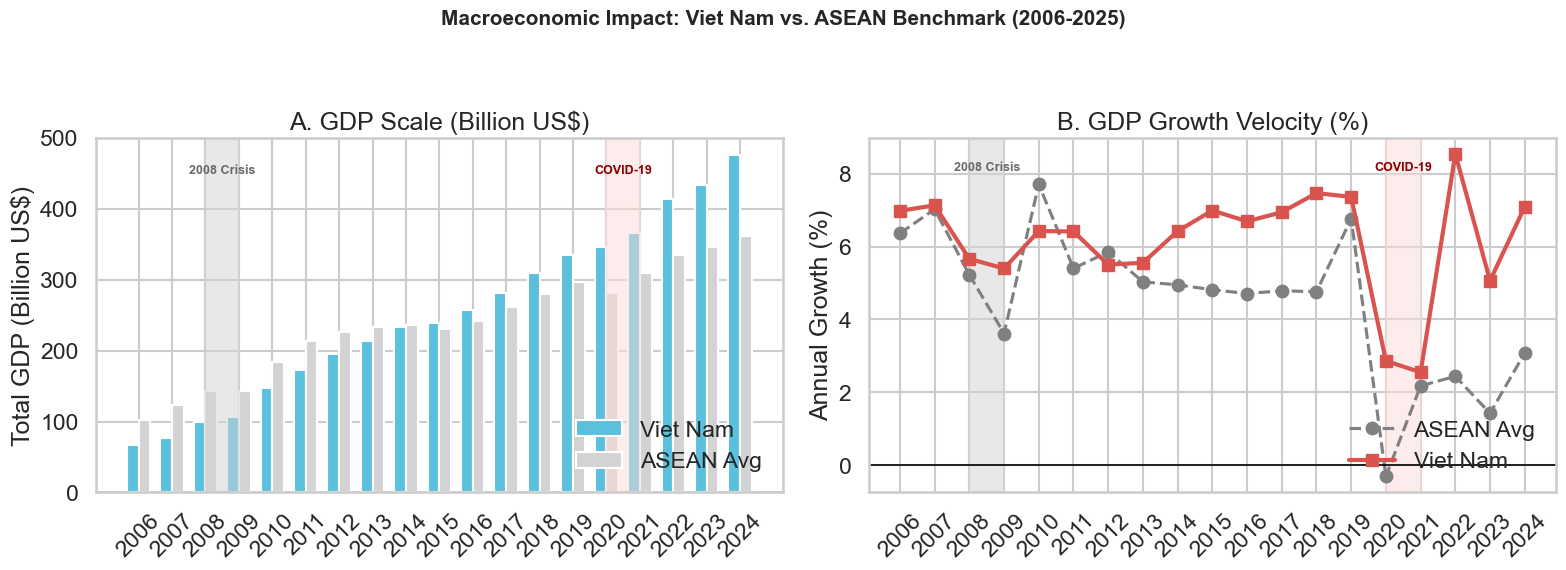

In [43]:
# 1. Prepare Data (Optimized: No merging needed)
df_q1 = df_final.dropna(subset=['GDP (current US$)', 'GDP growth (annual %)'])
df_vn = df_q1[df_q1['Country Name'] == 'Viet Nam']
asean_avg = df_q1.groupby('Year').mean(numeric_only=True)

years = df_vn['Year'].values
w = 0.35 # Bar width

# 2. Plotting Setup (1 Row, 2 Columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# --- CHART A: GDP SCALE (Grouped Bars) ---
vn_gdp_b = df_vn['GDP (current US$)'] / 1e9
as_gdp_b = asean_avg['GDP (current US$)'] / 1e9

ax1.bar(years - w/2, vn_gdp_b, w, label='Viet Nam', color='#5BC0DE')
ax1.bar(years + w/2, as_gdp_b, w, label='ASEAN Avg', color='#D3D3D3')
ax1.set(title="A. GDP Scale (Billion US$)", ylabel="Total GDP (Billion US$)")
ax1.legend(loc='lower right')

# --- CHART B: GDP GROWTH (Lines) ---
ax2.plot(years, asean_avg['GDP growth (annual %)'], '--o', color='grey', label='ASEAN Avg')
ax2.plot(years, df_vn['GDP growth (annual %)'], '-s', color='#D9534F', lw=3, label='Viet Nam')
ax2.axhline(0, color='black', lw=1.2) # 0% baseline
ax2.set(title="B. GDP Growth Velocity (%)", ylabel="Annual Growth (%)")
ax2.legend(loc='lower right')

# --- 3. Formatting & Crisis Highlights (Applied to both charts) ---
for ax in (ax1, ax2):
    ax.set_xticks(years)
    ax.tick_params(axis='x', rotation=45)
    
    # Highlight crises
    ax.axvspan(2008, 2009, color='lightgray', alpha=0.5)
    ax.axvspan(2020, 2021, color='#FADBD8', alpha=0.5)
    
    # Add text labels (auto-positioned near the top)
    y_pos = ax.get_ylim()[1] * 0.9
    ax.text(2008.5, y_pos, '2008 Crisis', ha='center', color='dimgray', fontsize=9, fontweight='bold')
    ax.text(2020.5, y_pos, 'COVID-19', ha='center', color='darkred', fontsize=9, fontweight='bold')

plt.suptitle("Macroeconomic Impact: Viet Nam vs. ASEAN Benchmark (2006-2025)", fontweight='bold', fontsize=15, y=1.05)
plt.tight_layout()
plt.show()

**Analysis & Conclusion:**
* **Growth Resilience:** The line chart reveals that during the 2020 COVID-19 pandemic, while the ASEAN average growth plunged into negative territory (recession), Vietnam maintained positive growth, showcasing exceptional resilience.
* **Scaling Up:** The bar chart demonstrates a "Catch-up Effect." In 2006, Vietnam's GDP scale was significantly below the ASEAN average. However, by 2024-2025, the gap has narrowed substantially, proving that Vietnam's consistent outperformance in growth is successfully translating into a much larger regional economic standing.

### **Objective 2: How does Vietnam's trade openness and reliance on imports/exports compare to the ASEAN regional average over the last 20 years?**

**Chart Selection & Rationale:**
* **What:** A combination of a **Stacked Area Chart** (illustrating Vietnam's structural trade components: Exports and Imports) and a benchmark **Line Chart** (representing the ASEAN Average Total Trade % of GDP).
* **Why:** * To evaluate trade structure, a **Stacked Area Chart** is superior to standard lines because it visually accumulates `Exports` and `Imports` to form the total `Trade (% of GDP)` volume. 
    * Adding the **Line Chart** for the ASEAN Average allows us to seamlessly benchmark Vietnam's overall economic openness against the typical regional standard without cluttering the structural data.
* **How:** We plot Vietnam's Exports (green area) and Imports (blue area) stacked on top of each other. The sum of these areas equals Vietnam's total trade openness. We then overlay a dashed black line representing the ASEAN average trade openness. This instantly highlights whether Vietnam is more integrated into the global supply chain than its peers, and whether that integration is export-led or import-reliant.

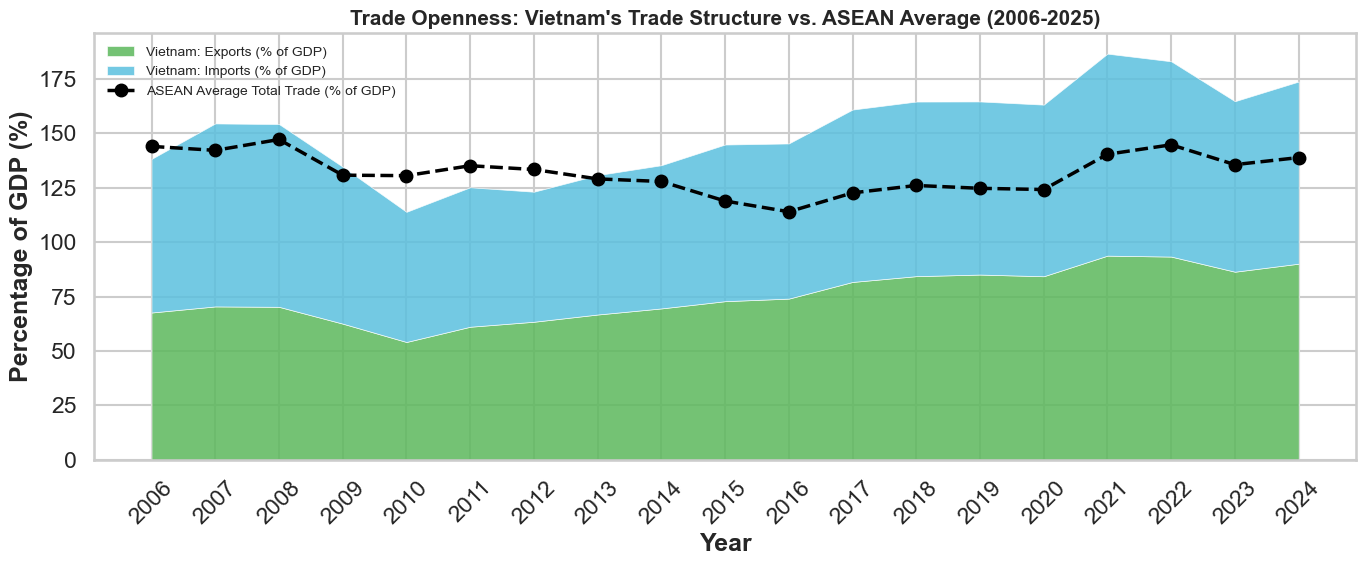

In [44]:
# 1. Prepare Data
cols = ['Country Name', 'Year', 'Trade (% of GDP)', 
        'Exports of goods and services (% of GDP)', 
        'Imports of goods and services (% of GDP)']
df_trade = df_final.dropna(subset=cols[2:]) # Drop rows missing trade metrics

# Vietnam's Data
df_vn = df_trade[df_trade['Country Name'] == 'Viet Nam'].sort_values('Year')

# ASEAN Average Total Trade
asean_avg_trade = df_trade.groupby('Year')['Trade (% of GDP)'].mean()

# 2. Plotting Setup
plt.figure(figsize=(14, 6))

# Define variables for stacking
years = df_vn['Year'].values
exports = df_vn['Exports of goods and services (% of GDP)'].values
imports = df_vn['Imports of goods and services (% of GDP)'].values

# --- CHART 1: Vietnam's Trade Structure (Stacked Area) ---
plt.stackplot(years, exports, imports, 
              labels=['Vietnam: Exports (% of GDP)', 'Vietnam: Imports (% of GDP)'],
              colors=['#5CB85C', '#5BC0DE'], alpha=0.85, edgecolor='white', lw=0.5)

# --- CHART 2: ASEAN Benchmark (Line) ---
plt.plot(asean_avg_trade.index, asean_avg_trade, '--o', color='black', lw=2.5, 
         label='ASEAN Average Total Trade (% of GDP)')

# 3. Formatting
plt.title("Trade Openness: Vietnam's Trade Structure vs. ASEAN Average (2006-2025)", fontsize=15, fontweight='bold')
plt.ylabel('Percentage of GDP (%)', fontweight='bold')
plt.xlabel('Year', fontweight='bold')
plt.xticks(np.sort(df_trade['Year'].unique()), rotation=45)

# Ensure Y-axis starts from 0 for accurate area representation
plt.ylim(bottom=0)

# Optimize Legend
plt.legend(loc='upper left', framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.show()

**Analysis & Conclusion:**
* **Explosive Openness:** The chart reveals a dramatic surge in Vietnam's trade openness. Starting from roughly 130% of GDP in 2006, the total trade volume (the top edge of the stacked area) skyrocketed to over 170% in recent years, leaving the ASEAN average (dashed line) far behind.
* **Structural Balance:** Looking at the internal structure, Vietnam has successfully maintained a relatively balanced ratio between imports and exports. However, in the latter half of the timeline, the export band (green) visibly widens and slightly overtakes imports (blue), confirming Vietnam's successful transition into an export-driven manufacturing hub.
* **Conclusion:** Vietnam is exceptionally integrated into the global economy, significantly outperforming the ASEAN average in trade openness. Its economic engine is highly reliant on international trade, making it a regional powerhouse but also exposing it to global supply chain vulnerabilities.

### **Objective 3: Internal Evolution of Vietnam’s FDI-to-High-Tech Correlation**

**Chart Selection & Rationale:**
* **What:** A **Connected Scatter Plot (Time-Series Trajectory)** focusing exclusively on Vietnam, using a **Color Gradient** to represent the passage of time.
* **Why:** A standard scatter plot shows correlation but loses the chronological "story." By connecting Vietnam’s data points in order of years, we visualize the **Developmental Path**. This reveals not just *if* FDI and Tech are related, but *how* the relationship has matured over 20 years. The color gradient (from light to dark red) adds a third dimension—Time—allowing the audience to track the economy's "flight path" without visual clutter.
* **How:** FDI (% of GDP) is mapped to the **X-axis** (The Input) and High-Tech Exports to the **Y-axis** (The Output). The connecting line shows the historical sequence, while milestone labels (2006, 2015, 2024) provide concrete anchors for the narrative of Vietnam's industrial transformation.

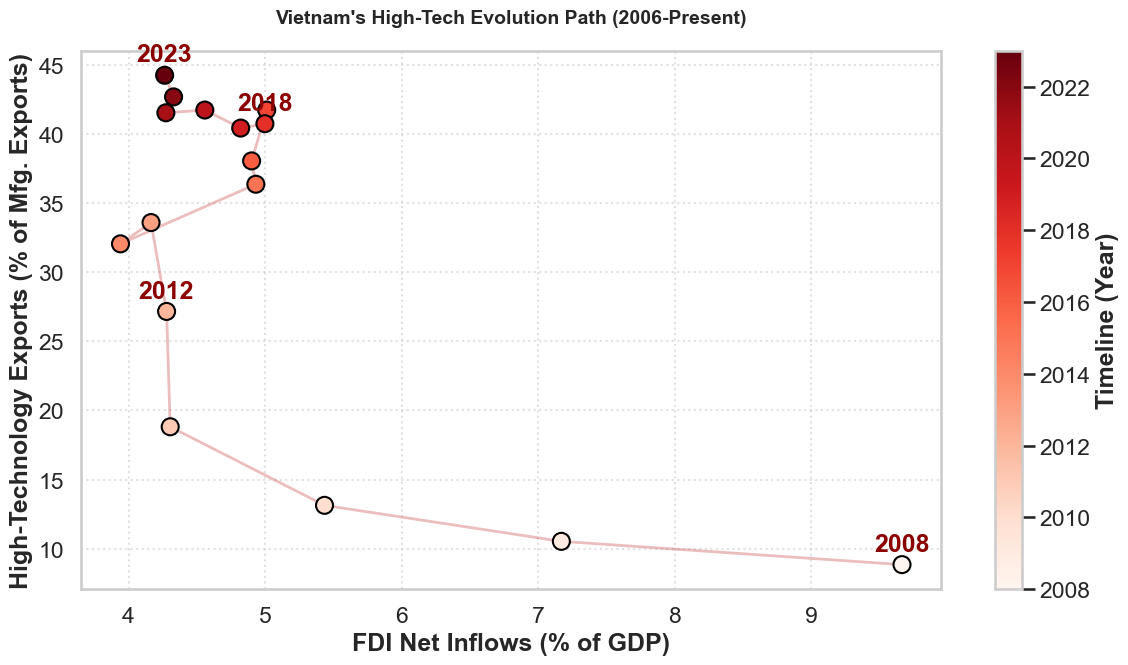

In [45]:
# 1. Define columns and filter data for Vietnam only
fdi_col = 'Foreign direct investment, net inflows (% of GDP)'
tech_col = 'High-technology exports (% of manufactured exports)'
df_vn = df_final[df_final['Country Name'] == 'Viet Nam'].dropna(subset=[fdi_col, tech_col]).sort_values('Year')

# 2. Initialize Plot
plt.figure(figsize=(12, 7))

# Draw the chronological path (connect dots in order of years)
plt.plot(df_vn[fdi_col], df_vn[tech_col], color='indianred', alpha=0.4, linewidth=2, zorder=1)

# Plot scatter dots with a color gradient representing Time (Year)
scatter = plt.scatter(df_vn[fdi_col], df_vn[tech_col], c=df_vn['Year'], cmap='Reds', 
                      s=150, edgecolor='black', zorder=2)

# 3. Annotate specific milestone years for better navigation
milestones = [df_vn['Year'].min(), 2012, 2018, df_vn['Year'].max()]
for _, row in df_vn.iterrows():
    if row['Year'] in milestones:
        plt.annotate(f"{int(row['Year'])}", (row[fdi_col], row[tech_col]),
                     xytext=(0, 10), textcoords="offset points", 
                     ha='center', fontweight='bold', color='darkred')

# 4. Formatting and Labels
plt.title("Vietnam's High-Tech Evolution Path (2006-Present)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel('FDI Net Inflows (% of GDP)', fontweight='bold')
plt.ylabel('High-Technology Exports (% of Mfg. Exports)', fontweight='bold')

# Add colorbar to explain the time gradient
plt.colorbar(scatter).set_label('Timeline (Year)', fontweight='bold')

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Analysis & Conclusion**

The chronological trajectory reveals three distinct phases based purely on the relationship between capital input and technological output:

* **Phase 1: High Input, Low Yield (2008 - 2012):** The data points start in the bottom-right. FDI inflows were highly volatile and peaked near 10% of GDP, yet the high-tech export share remained stagnant below 10%. This indicates a period of heavy capital absorption without immediate high-tech generation (a temporal lag).
* **Phase 2: The Vertical Surge (2012 - 2018):** The trajectory shifts sharply upward. While the FDI-to-GDP ratio stabilized at a lower level (around 4-5%), the high-tech export share grew exponentially from ~20% to over 40%. This demonstrates a massive increase in the efficiency of converting foreign capital into high-tech manufacturing output.
* **Phase 3: High-Level Plateau (2018 - 2023):** The darkest data points cluster tightly at the top of the Y-axis. The high-tech export share maintains a stable, high baseline of 40-45% while FDI inflows remain consistent, indicating a finalized and stabilized structural shift.

**Conclusion:** The data proves a delayed but exponential correlation. An initial phase of intense FDI accumulation was subsequently followed by a vertical surge in high-tech export capacity, permanently elevating Vietnam's structural position on the Y-axis.

## 3.2 Health & Public Health

### **Objective 1: How has the historical trend of health expenditure driven long-term improvements in Vietnam's public health outcomes?**

**Chart Selection & Rationale:**
* **What:** A **Dual-Axis Combo Chart (Time-Series)** focusing exclusively on Vietnam's historical data.
* **Why:** To truly understand healthcare efficiency, a single-year snapshot is insufficient because health investments (like building hospitals or training doctors) have a delayed impact. We need to track the chronological evolution to see if sustained financial commitment successfully translates into steady health improvements. A combo chart is the perfect tool to compare variables with entirely different units (Percentages vs. Years/Rates) over the same timeline.
* **How:** The **X-axis** represents the chronological timeline (Years). The **Primary Y-axis** displays Health Expenditure as background bars (The Input). The **Secondary Y-axis** overlays Life Expectancy and Mortality Rates as solid, continuous lines (The Outputs). This visual configuration allows the audience to instantly observe whether the "Output lines" are improving in response to the "Input bars" over the 20-year span.

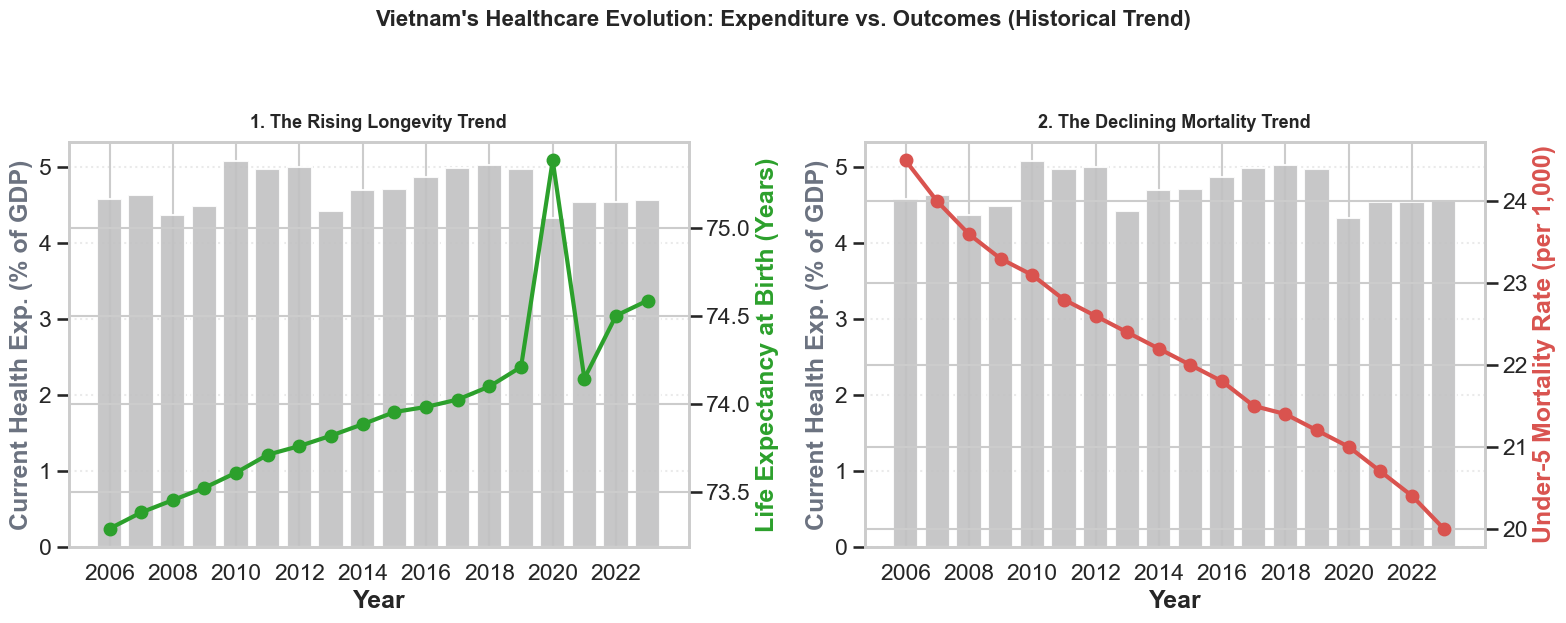

In [46]:
# 1. Setup columns and filter chronological data for Vietnam only
c_exp = 'Current health expenditure (% of GDP)'
c_life = 'Life expectancy at birth, total (years)'
c_mort = 'Mortality rate, under-5 (per 1,000 live births)'

df_vn = df_final[df_final['Country Name'] == 'Viet Nam'].dropna(subset=[c_exp, c_life, c_mort, 'Year']).sort_values('Year')
years = df_vn['Year'].astype(int)

# 2. Initialize the side-by-side figure (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Vietnam's Healthcare Evolution: Expenditure vs. Outcomes (Historical Trend)", 
             fontsize=16, fontweight='bold', y=1.05)

# --- 1: EXPENDITURE (Bars) vs. LIFE EXPECTANCY (Line) ---
ax1 = axes[0]
# Plot Input (Expenditure) as light bars on the Primary Y-axis
ax1.bar(years, df_vn[c_exp], color="#C1C1C2", alpha=0.9, label='Health Exp. (% GDP)')
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Current Health Exp. (% of GDP)', color='#6B7280', fontweight='bold')
ax1.set_xticks(years[::2]) # Show every 2nd year to avoid crowding

# Plot Output (Life Expectancy) as a bold line on the Secondary Y-axis
ax1_twin = ax1.twinx()
ax1_twin.plot(years, df_vn[c_life], color='#2CA02C', marker='o', linewidth=3, label='Life Expectancy')
ax1_twin.set_ylabel('Life Expectancy at Birth (Years)', color='#2CA02C', fontweight='bold')
ax1.set_title("1. The Rising Longevity Trend", fontsize=13, fontweight='bold', pad=10)

# --- 2: EXPENDITURE (Bars) vs. UNDER-5 MORTALITY (Line) ---
ax2 = axes[1]
# Plot Input (Expenditure) as light bars on the Primary Y-axis
ax2.bar(years, df_vn[c_exp], color='#C1C1C2', alpha=0.9)
ax2.set_xlabel('Year', fontweight='bold')
ax2.set_ylabel('Current Health Exp. (% of GDP)', color='#6B7280', fontweight='bold')
ax2.set_xticks(years[::2])

# Plot Output (Mortality) as a bold line on the Secondary Y-axis
ax2_twin = ax2.twinx()
ax2_twin.plot(years, df_vn[c_mort], color='#D9534F', marker='o', linewidth=3, label='Under-5 Mortality')
ax2_twin.set_ylabel('Under-5 Mortality Rate (per 1,000)', color='#D9534F', fontweight='bold')
ax2.set_title("2. The Declining Mortality Trend", fontsize=13, fontweight='bold', pad=10)

# 3. Final Formatting
for ax in [ax1, ax2]:
    ax.grid(True, linestyle=':', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. Direct Observations**
* **Stagnant Input (Grey Bars):** Over nearly two decades (2006 - 2023), Vietnam's health expenditure remained remarkably stable, fluctuating within a narrow band of 4.3% to 5.1% of GDP. There was no trend of sudden or massive budget expansion.
* **Consistent Survival Gains (Red Line):** Despite the stagnant health expenditure ratio, the under-5 mortality rate declined continuously, steadily, and linearly (dropping from over 24 down to approximately 20 deaths per 1,000 live births). This downward trajectory was perfectly consistent, unbroken by any yearly anomalies.
* **Longevity Growth & The 2020-2021 "Shock" (Green Line):** From 2006 to 2019, average life expectancy grew at a steady, upward pace. However, the data reveals a drastic fluctuation: a sharp spike in 2020 followed by a deep plunge in 2021, before bouncing back in 2022-2023. This is the distinct demographic footprint of the COVID-19 pandemic on public health.


**2. Efficiency Optimization over Budget Expansion.**
The data clearly proves that Vietnam's healthcare transformation—particularly in protecting child life—did not depend on aggressively inflating health spending as a percentage of GDP. Vietnam successfully generated an exceptionally high Return on Investment (ROI): utilizing a relatively stable budget ratio while sustaining long-term momentum in health improvements.

**3. Deeper Implications**
* **The Strength of Primary Healthcare:** The uninterrupted decline in child mortality (the red line), entirely unaffected by the pandemic or budget plateaus, demonstrates that Vietnam's preventive healthcare system possesses immense resilience and sustainability.
* **Vulnerability to Global Shocks:** The severe fluctuation in the life expectancy curve (the green line) during 2020-2021 highlights a critical reality: No matter how highly efficient the health system is at managing standard pathologies, overall population longevity remains highly vulnerable to global epidemiological disasters (COVID-19).

### **Objective 2: How strong is the inverse correlation between immunization coverage and child mortality rates?**
**Chart Selection & Rationale:**

* **What:** A **Two-Panel Visualization** consisting of:
  - A Scatter Plot with Regression Line (ASEAN context)  
  - A Trajectory Plot (Vietnam)

* **Why:** A scatter plot is the most appropriate method to capture the **inverse relationship between two continuous variables**. However, correlation alone does not reflect temporal dynamics, so a trajectory plot is added to track Vietnam’s progress over time.

* **How:** Panel 1 plots all ASEAN observations with a regression line to show the overall trend, while highlighting Vietnam. Panel 2 visualizes Vietnam’s trajectory by connecting data points over time, using color to represent years and annotating key milestones to clearly show the improvement path (immunization ↑, mortality ↓).

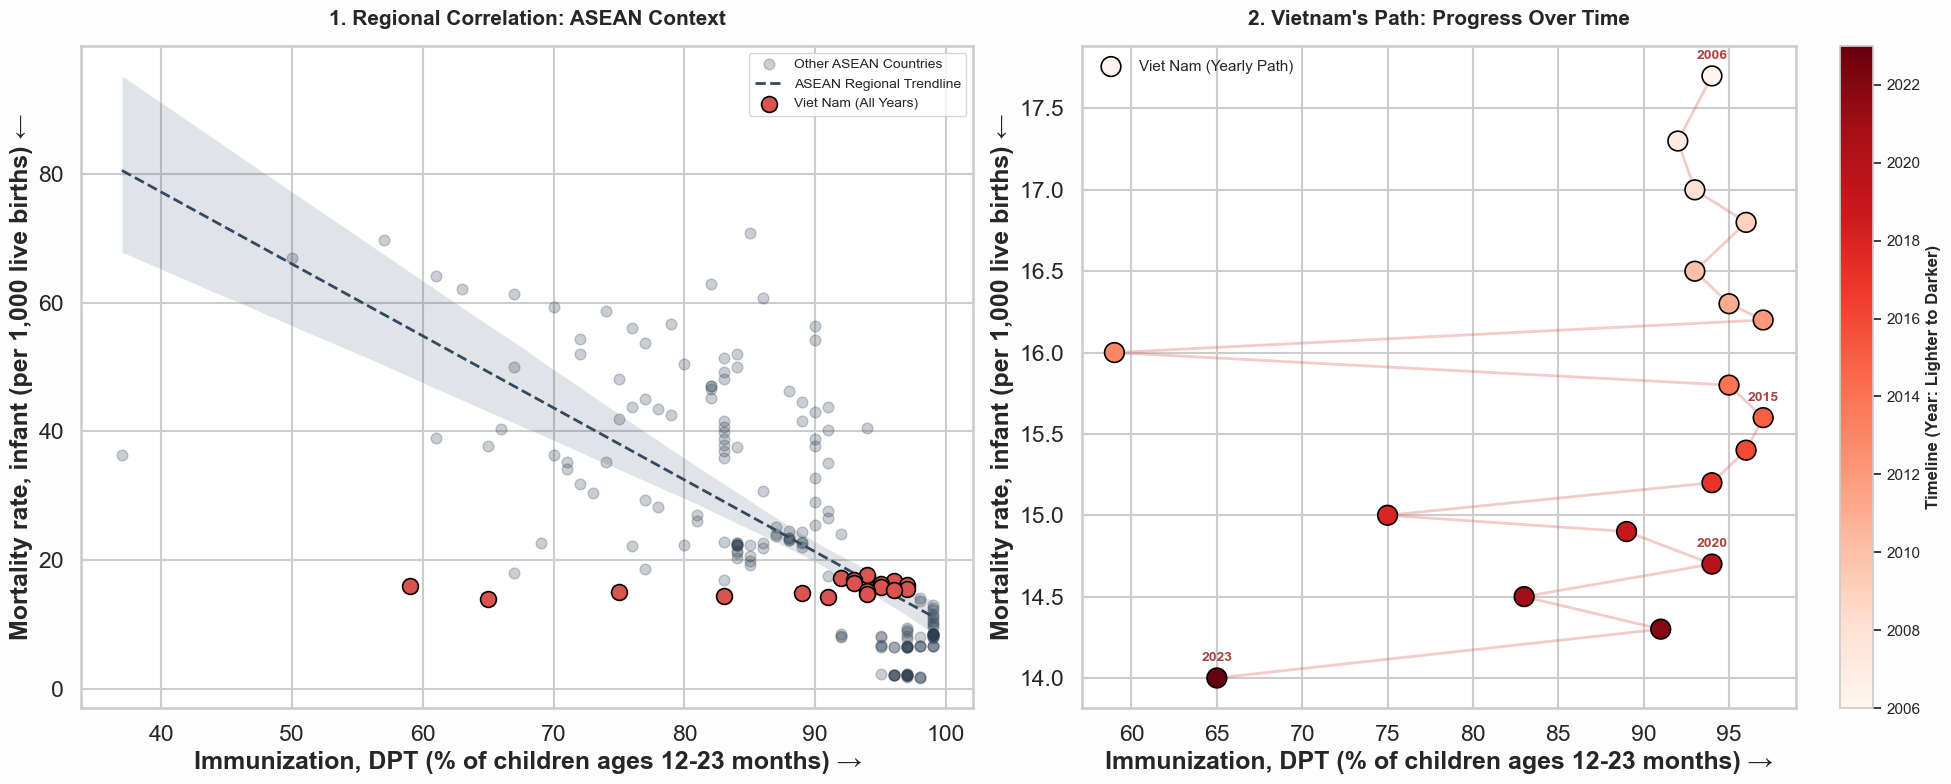

In [47]:
# 1. Setup data and filter
c_immu = 'Immunization, DPT (% of children ages 12-23 months)'
c_infant_mort = 'Mortality rate, infant (per 1,000 live births)'

df_corr = df_final.dropna(subset=[c_immu, c_infant_mort, 'Country Name', 'Year']).copy()
df_corr = df_corr[df_corr['Year'] >= 2006] 

df_vn = df_corr[df_corr['Country Name'] == 'Viet Nam'].sort_values('Year')
df_others = df_corr[df_corr['Country Name'] != 'Viet Nam']

# 2. Initialize a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8), facecolor='#FDFDFD')
sns.set_theme(style="whitegrid")

# PANEL 1: REGIONAL CONTEXT (ASEAN Correlation)
ax1 = axes[0]

# Plot background ASEAN countries first
ax1.scatter(df_others[c_immu], df_others[c_infant_mort], 
            color='#2C3E50', alpha=0.25, s=60, label='Other ASEAN Countries', zorder=2)

# Plot the Regional Regression Line
sns.regplot(data=df_corr, x=c_immu, y=c_infant_mort, scatter=False, 
            line_kws={'color':'#34495E', 'linewidth':2, 'linestyle':'--'}, 
            label='ASEAN Regional Trendline', ax=ax1)

# Highlight Vietnam points in the regional context
ax1.scatter(df_vn[c_immu], df_vn[c_infant_mort], 
            color='#D9534F', s=130, edgecolor='black', linewidth=1.2, 
            zorder=5, label='Viet Nam (All Years)')

ax1.set_title("1. Regional Correlation: ASEAN Context", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel(f"{c_immu} →", fontweight='bold')
ax1.set_ylabel(f"{c_infant_mort} ←", fontweight='bold')
ax1.legend(loc='upper right', frameon=True, fontsize=10) 

# PANEL 2: VIETNAM DEEP DIVE (The Survival Trajectory)
ax2 = axes[1]

# Draw the trajectory path
ax2.plot(df_vn[c_immu], df_vn[c_infant_mort], color='#D9534F', alpha=0.3, linewidth=2, zorder=1)

# Scatter points with color gradient (Darker = More recent)
scatter = ax2.scatter(df_vn[c_immu], df_vn[c_infant_mort], 
                      c=df_vn['Year'], cmap='Reds', s=200, 
                      edgecolor='black', linewidth=1.2, zorder=2, label='Viet Nam (Yearly Path)')

# Annotate specific milestones
for i, row in df_vn.iterrows():
    if row['Year'] in [df_vn['Year'].min(), 2015, 2020, df_vn['Year'].max()]:
        ax2.annotate(int(row['Year']), 
                     (row[c_immu], row[c_infant_mort]),
                     textcoords="offset points", xytext=(0, 12), 
                     ha='center', fontweight='bold', fontsize=10, color='#A94442')

# Colorbar for the year gradient
cbar = fig.colorbar(scatter, ax=ax2)
cbar.set_label('Timeline (Year: Lighter to Darker)', fontweight='bold')

ax2.set_title("2. Vietnam's Path: Progress Over Time", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel(f"{c_immu} →", fontweight='bold')
ax2.set_ylabel(f"{c_infant_mort} ←", fontweight='bold')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. Regional Correlation Analysis (Panel 1: ASEAN Context)**
- **Strong Inverse Correlation:** The downward-sloping regression line (dashed line) confirms a powerful negative correlation across the ASEAN region. As DPT immunization coverage increases, the infant mortality rate consistently decreases.
- **High-Performance Standing (Vietnam):** Vietnam’s data points (red dots) are densely clustered in the "Optimal Survival Zone" (bottom-right corner). Compared to the regional average, Vietnam maintains a significantly lower mortality rate than many neighboring countries with similar or even higher vaccination levels.

- **Statistical Reliability:** The narrowing of the confidence interval (grey shaded area) as immunization exceeds 80% suggests that the "Vaccine Shield" effect becomes highly predictable and effective at higher coverage levels.

**2. Panel 2: Progress Over Time**
- **Progressive Gains (2006–2015)**: Vietnam began 2006 with an infant mortality rate of ~17.7 and ~94% immunization. By 2015, the country reached its peak immunization coverage (~97%), which successfully drove the mortality rate down to ~15.7.
- **Stable Improvements (2015–2020)**: Despite slight fluctuations in DPT coverage (stabilizing around 94–95%), the mortality rate continued its steady decline to approximately 14.7 per 1,000 live births.
- **Resilience Test (2023)**: This is the most significant data anomaly. In 2023, DPT immunization coverage experienced a sharp drop to ~65% (shifting far left on the X-axis). However, the infant mortality rate reached its historic low of 14.0 (dropping to the bottom of the Y-axis).

**3. Strategic Insights**
- **Systemic Resilience:** The chart demonstrates that Vietnam's progress in reducing infant mortality is sustainable. The mortality rate did not rebound even when immunization coverage faced a temporary, severe disruption in 2023.

- **“Accumulated Shield” Effect:** The consistent high coverage maintained between 2006 and 2020 likely created a deep "accumulated immunity" and a robust primary healthcare foundation. This allowed the survival rate to improve even during short-term volatility in the vaccination supply chain.


### **Objective 3: How have adolescent and total fertility rates shifted as contraceptive prevalence increases?**

**Chart Selection & Rationale:**

* **What:** A **Dual-Panel, Dual-Axis Area and Line Chart**.
* **Why:** To visualize causality over time, we need a chart that overlays the "intervention" and the "outcome" without cluttering the screen. 
    * The **Area Chart (Purple)** effectively represents "Volume and Accumulation"—showing how the protective layer of family planning has expanded and solidified in society.
    * The **Line Chart** represents the "Trajectory of the Consequence." By placing the descending lines over the rising area, the chart mathematically illustrates the "squeeze effect": the expansion of contraceptive access physically pushes fertility rates downward. 
    * Using a **Dual-Panel** layout allows us to isolate the general demographic shift (Total Fertility) from the critical public health victory of protecting vulnerable youth (Adolescent Fertility).
* **How:** * **X-axis:** The historical timeline (Year).
    * **Left Y-axis (Primary):** `Contraceptive prevalence (%)`, plotted as a filled area chart moving upwards (↑).
    * **Right Y-axis (Secondary):** `Fertility Rate`, plotted as a descending line chart (↓).
    * **Panel 1** tracks the general population, while **Panel 2** isolates the impact on teenagers.

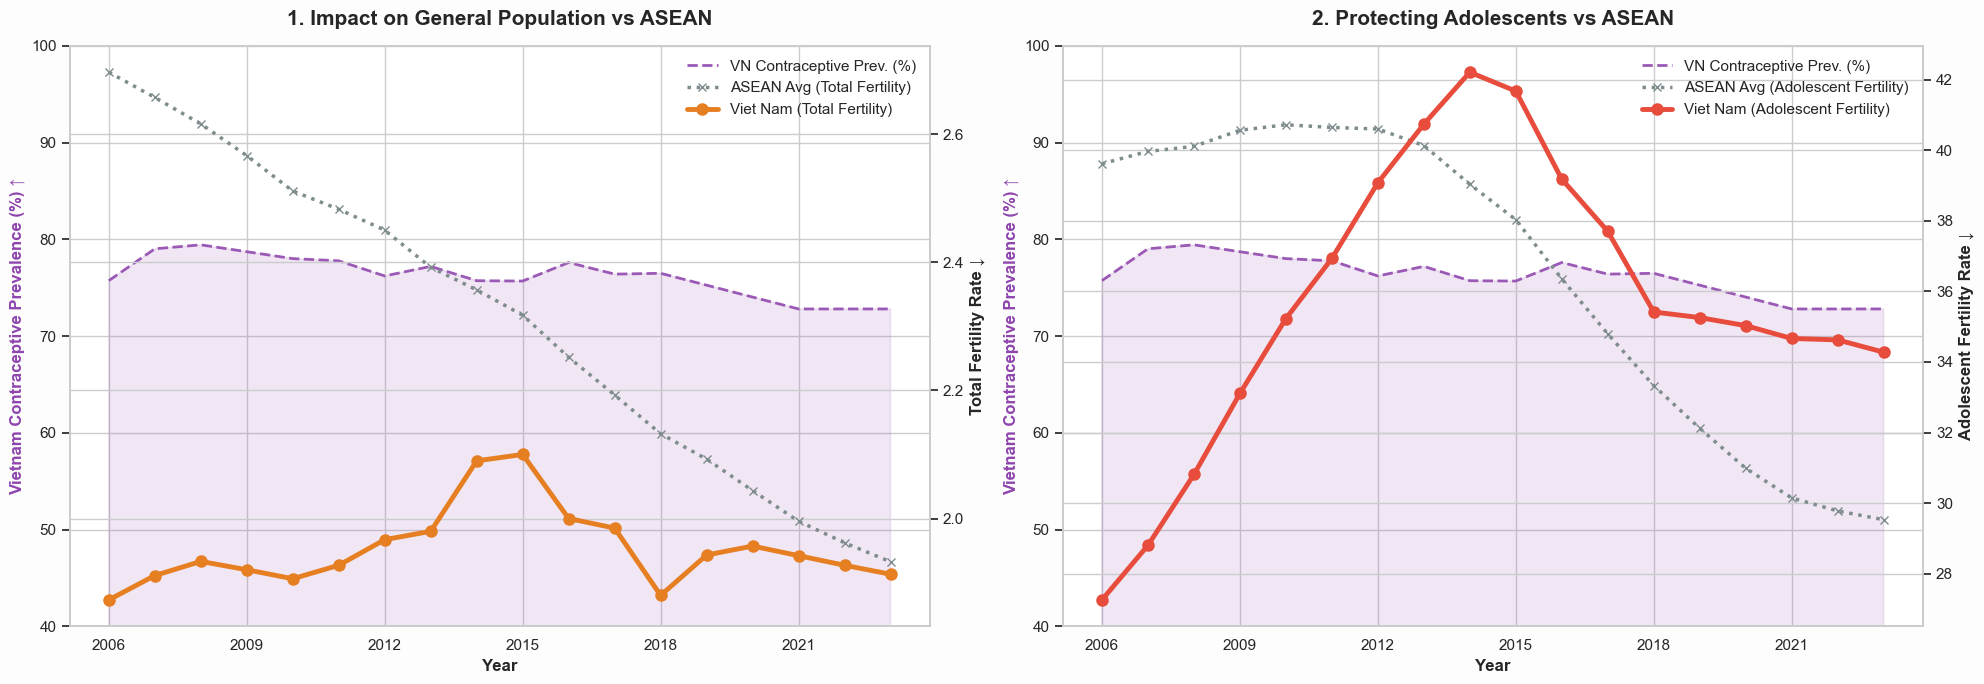

In [48]:
# 1. Define variables
c_tf = 'Fertility rate, total (births per woman)'
c_af = 'Adolescent fertility rate (births per 1,000 women ages 15-19)'
c_cp = 'Contraceptive prevalence, any method (% of married women ages 15-49)'

# 2. Prepare Vietnam Data (Interpolate missing CP values)
df_vn = df_final[df_final['Country Name'] == 'Viet Nam'].sort_values('Year').copy()
df_vn[c_cp] = df_vn[c_cp].interpolate(method='linear').ffill().bfill()
df_vn_plot = df_vn.dropna(subset=[c_tf, c_af, c_cp, 'Year'])
years = df_vn_plot['Year'].astype(int)

# 3. Prepare ASEAN Benchmark Data (Mean of all countries per year)
# Ensure we only calculate mean for years that exist in our Vietnam plot timeline
df_asean = df_final.dropna(subset=[c_tf, c_af, 'Year'])
asean_avg = df_asean.groupby('Year')[[c_tf, c_af]].mean().reset_index()
asean_avg_plot = asean_avg[asean_avg['Year'].isin(years)]

# 4. Initialize Figure (Dual-Panel)
fig, axes = plt.subplots(1, 2, figsize=(20, 7), facecolor='#FDFDFD')
sns.set_theme(style="whitegrid")

targets = [(c_tf, "1. Impact on General Population vs ASEAN", '#E67E22', 'Total Fertility'), 
           (c_af, "2. Protecting Adolescents vs ASEAN", '#E74C3C', 'Adolescent Fertility')]

# 5. Plotting Loop
for ax, (col, title, color, short_name) in zip(axes, targets):
    ax_twin = ax.twinx() 
    
    # 5.1 Plot Vietnam's Intervention (Area Chart - Left Y-axis)
    ax.fill_between(years, 0, df_vn_plot[c_cp], color='#9B59B6', alpha=0.15)
    ax.plot(years, df_vn_plot[c_cp], color='#9B59B6', lw=2, ls='--', label='VN Contraceptive Prev. (%)')
    
    # 5.2 Plot ASEAN Average Outcome (Grey Dotted Line - Right Y-axis)
    ax_twin.plot(asean_avg_plot['Year'], asean_avg_plot[col], color='#7F8C8D', lw=2.5, ls=':', 
                 marker='x', markersize=6, label=f'ASEAN Avg ({short_name})')
                 
    # 5.3 Plot Vietnam's Outcome (Solid Colored Line - Right Y-axis)
    ax_twin.plot(years, df_vn_plot[col], color=color, lw=3.5, marker='o', 
                 markersize=8,  label=f'Viet Nam ({short_name})')
    
    # Formatting
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel('Year', fontweight='bold', fontsize=12)
    ax.set_ylabel('Vietnam Contraceptive Prevalence (%) ↑', color='#8E44AD', fontweight='bold')
    ax_twin.set_ylabel(f'{short_name} Rate ↓', fontweight='bold')
    
    ax.set_ylim(40, 100) # Baseline for Contraceptive area
    ax.set_xticks(years[::3])
    
    # Combine Legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    ax_twin.legend(lines + lines2, labels + labels2, loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.show()

**Analysis & Conclusion**  

**1. General Population Stability**
- **The Lead in Stability**: While the ASEAN average (grey dotted line) underwent a massive demographic transition—dropping from a high of ~2.7 in 2006 to ~1.9 in 2023—Vietnam (orange line) had already achieved stability.

- **Regional Benchmarking**: Throughout the 2006–2018 period, Vietnam's fertility rate consistently remained below the regional average. This indicates that Vietnam reached demographic maturity and stabilized at the "replacement level" (~2.0) nearly two decades ahead of many of its neighbors.

- **Causal Link**: The high and sustained contraceptive prevalence acted as a reliable anchor, preventing the high-fertility fluctuations experienced by the broader ASEAN region during the previous decade.

**2. The Adolescent Fertility Challenge**
- **The Protection Gap (2006–2014)**: Contrary to the steady decline seen in the ASEAN average, Vietnam’s adolescent birth rate (red line) experienced a sharp spike, nearly doubling from a historic low of ~27 to a peak of >42.

- **Crossing the Regional Benchmark**: Around 2012, Vietnam’s adolescent fertility trajectory crossed above the ASEAN average. While the rest of the region was successfully protecting vulnerable youth from early pregnancy, Vietnam faced an internal crisis where adolescent fertility rose despite high overall contraceptive use.

- **Recent Recovery**: A significant downward "plunge" began after 2015. However, as of 2023 (~34), Vietnam’s adolescent fertility rate remains higher than the ASEAN average (~29.5).

**Core Insights**: While Vietnam acts as a regional leader in Macro-Demographic Stability (Total Fertility Rate consistently below the ASEAN average), it faces a persistent Micro-Vulnerability in adolescent reproductive health. Despite a robust contraceptive "shield" (>70% coverage), the adolescent birth rate remains a critical anomaly, currently exceeding the regional benchmark. This highlights a shift in policy priority: moving from general coverage volume to targeted, high-quality access for vulnerable youth populations.

## 3.3 Education & Innovation

### **Objective 1: Did the boom in internet/mobile coverage coincide with an increase in school enrollment rates?**

**Chart Selection & Rationale:**

* **What:** A **Regional Scatter Plot with a Linear Regression Trendline**, highlighting Vietnam's historical data points.
* **Why:** * To prove a *correlation*, a scatter plot is the most statistically accurate visual tool. It allows us to plot two continuous variables against each other to reveal underlying patterns.
    * The **ASEAN Trendline (Dashed Line)** is the most critical element: it acts as the "Regional Benchmark". It establishes the expected rate of tertiary enrollment for any given level of mobile penetration in Southeast Asia. 
    * By layering Vietnam's specific data points (large colored dots) over the regional background (gray dots), we can instantly evaluate performance. If Vietnam's dots sit *above* the trendline, it proves our nation is highly efficient at converting digital infrastructure into educational success compared to our neighbors.
* **How:** * **X-axis:** The "Enabler" — `Mobile cellular subscriptions (per 100 people)`.
    * **Y-axis:** The "Outcome" — `School enrollment, tertiary (% gross)`.
    * **Visual Layering:** Gray background dots represent the broader ASEAN context, the dashed line defines the mathematical correlation, and the prominent blue dots trace Vietnam's specific developmental footprint.

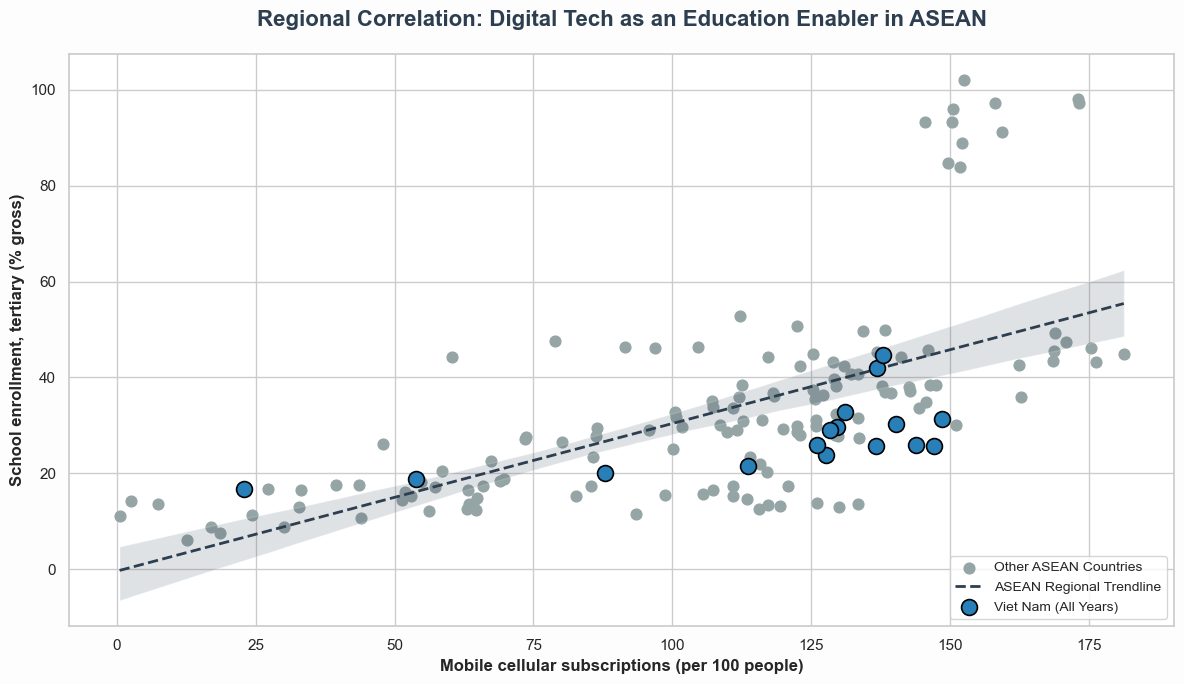

In [49]:
# 1. Define standard World Bank indicators
c_tech = 'Mobile cellular subscriptions (per 100 people)'
c_edu = 'School enrollment, tertiary (% gross)'

# 2. Data Preparation
df_plot = df_final.dropna(subset=[c_tech, c_edu, 'Country Name']).copy()

# Separate Vietnam and other ASEAN countries
df_vn = df_plot[df_plot['Country Name'] == 'Viet Nam']
df_others = df_plot[df_plot['Country Name'] != 'Viet Nam']

# 3. Initialize Standalone Figure
plt.figure(figsize=(12, 7), facecolor='#FDFDFD')
sns.set_theme(style="whitegrid")

# Plot ASEAN benchmark points (background)
plt.scatter(df_others[c_tech], df_others[c_edu], 
            color='#95A5A6', alpha=1, s=60, label='Other ASEAN Countries')

# Add Regional Trendline (Positive Correlation)
sns.regplot(data=df_plot, x=c_tech, y=c_edu, scatter=False, 
            line_kws={'color':'#2C3E50', 'linewidth':2, 'linestyle':'--'}, 
            label='ASEAN Regional Trendline')

# Highlight Vietnam's journey on the scatter plot (foreground)
plt.scatter(df_vn[c_tech], df_vn[c_edu], 
            color='#2980B9', s=130, edgecolor='black', linewidth=1.2, 
            zorder=5, label='Viet Nam (All Years)')

# Formatting and Storytelling
plt.title("Regional Correlation: Digital Tech as an Education Enabler in ASEAN", 
          fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
plt.xlabel(f"{c_tech}", fontweight='bold', fontsize=12)
plt.ylabel(f"{c_edu}", fontweight='bold', fontsize=12)

plt.legend(loc='lower right', frameon=True, fontsize=10)

plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. The Regional Rule (Positive Correlation):**
The upward-sloping dashed trendline and its confidence interval confirm our core hypothesis: there is a strong **positive correlation** between digital infrastructure and higher education across the ASEAN region. As mobile cellular subscriptions (X-axis) expand, tertiary school enrollment (Y-axis) predictably rises. Digital connectivity undeniably acts as an enabler for advanced learning.

**2. Vietnam's Synchronized Trajectory:**
Observing Vietnam's data points (large blue circles), there is a clear historical migration from the bottom-left (low connectivity, low enrollment) toward the right. This confirms that Vietnam follows the regional macro-trend: the national "mobile boom" successfully coincided with an expansion in university and college enrollment. 

**3. The Critical Insight (Underperformance against the Benchmark):**
The most crucial analytical finding lies in Vietnam's position relative to the regional benchmark. Particularly in the era of hyper-connectivity (ranging from 110 to 150 mobile subscriptions per 100 people), Vietnam's data points consistently fall **below the ASEAN regional trendline**. 

* **The Implication:** While Vietnam has successfully built a highly connected society (abundant infrastructure and devices), it is **underperforming** relative to regional expectations in converting this digital leverage into advanced educational outcomes. By contrast, several other ASEAN nations (represented by the gray dots in the upper-right quadrant) achieve vastly higher tertiary enrollment rates (80%–100%) with similar or even lower mobile penetration. 
* **Conclusion:** Vietnam does not lack "digital tools," but it may lack the socioeconomic "catalysts" (e.g., educational policies, financial support, or institutional capacity) needed to maximize the educational returns of its technological boom.

### **Objective 2: How does Vietnam's R&D investment and subsequent service sector growth benchmark against the ASEAN average during the 2011-2019 transition period?**

**Chart Selection & Rationale:**
* **What:** A **Regional Benchmarking Dual-Axis Chart** featuring Grouped Bars and Dual Lines.
* **Why:** * This format perfectly visually separates the "cause" from the "effect" while enabling direct regional comparison.
    * **The Grouped Bars** allow for a clear, side-by-side comparison of the financial "injections" (R&D) between Vietnam and the ASEAN average.
    * **The Dual Lines** act as continuous trend monitors, showing how the macroeconomic structure (Services) reacted to those investments.
    * **Aesthetic Choice:** We intentionally removed explicit data labels (numbers) from the bars and lines. This forces the viewer's eye to focus on the **Macro-Trend** (the upward slopes) and the **Capability Gap** (the physical distance between the Vietnam and ASEAN data points) rather than getting lost in micro-decimals.
* **How:** * **X-axis:** The 5 biennial milestones.
    * **Left Y-axis (Bars):** R&D Expenditure. Blue represents Vietnam; Gray establishes the ASEAN baseline.
    * **Right Y-axis (Lines):** Services Value Added. Orange represents Vietnam's trajectory; Dashed Gray traces the ASEAN regional expectation.

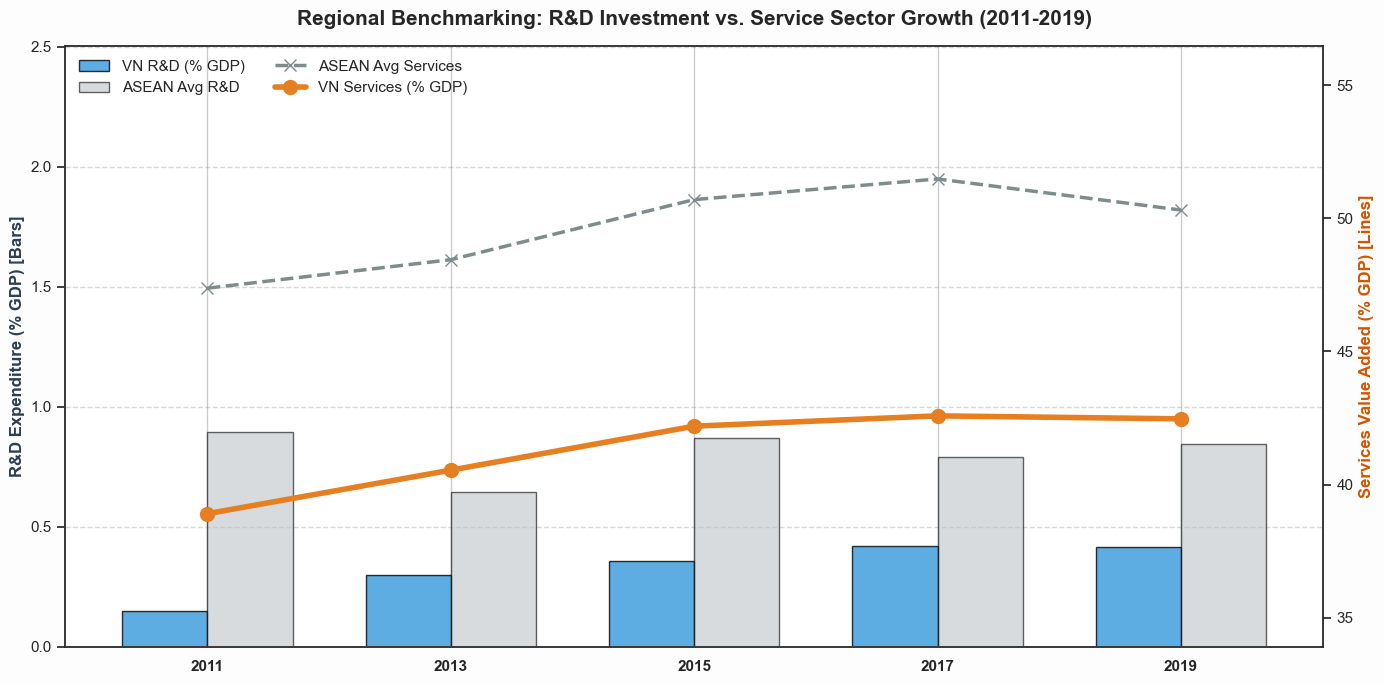

In [50]:
# 1. Define metrics and target years
c_rnd = 'Research and development expenditure (% of GDP)'
c_srv = 'Services, value added (% of GDP)'
target_years = [2011, 2013, 2015, 2017, 2019]

# 2. Data Preparation: Vietnam vs ASEAN Average
df_vn = df_final[(df_final['Country Name'] == 'Viet Nam') & (df_final['Year'].isin(target_years))].sort_values('Year').copy()
df_vn[c_rnd] = df_vn[c_rnd].interpolate(method='linear').ffill().bfill() # Handle missing R&D data

df_asean = df_final[(df_final['Country Name'] != 'Viet Nam') & (df_final['Year'].isin(target_years))]
asean_avg = df_asean.groupby('Year')[[c_rnd, c_srv]].mean().reset_index()

x_idx = np.arange(len(target_years))
width = 0.35 

# 3. Initialize Figure
fig, ax1 = plt.subplots(figsize=(14, 7), facecolor='#FDFDFD')
sns.set_style("white") 

# --- AXIS 1: R&D Expenditure (Grouped Bars) ---
ax1.bar(x_idx - width/2, df_vn[c_rnd], width, color='#3498DB', alpha=0.8, edgecolor='black', label='VN R&D (% GDP)')
ax1.bar(x_idx + width/2, asean_avg[c_rnd], width, color='#BDC3C7', alpha=0.6, edgecolor='black', label='ASEAN Avg R&D')

ax1.set_ylabel('R&D Expenditure (% GDP) [Bars]', color='#2C3E50', fontweight='bold')
ax1.set_xticks(x_idx)
ax1.set_xticklabels(target_years, fontweight='bold', fontsize=11)

ax1.grid(True, axis='y', color='gray', linestyle='--', alpha=0.3)
ax1.set_ylim(0, max(df_vn[c_rnd].max(), asean_avg[c_rnd].max()) * 2.8) 

# --- AXIS 2: Services Value Added (Dual Lines) ---
ax2 = ax1.twinx()
ax2.plot(x_idx, asean_avg[c_srv], color='#7F8C8D', marker='x', ms=8, lw=2.5, ls='--', label='ASEAN Avg Services')
ax2.plot(x_idx, df_vn[c_srv], color='#E67E22', marker='o', ms=10, lw=4, label='VN Services (% GDP)')

ax2.set_ylabel('Services Value Added (% GDP) [Lines]', color='#D35400', fontweight='bold')

ax2.grid(False) 
ax2.set_ylim(min(df_vn[c_srv].min(), asean_avg[c_srv].min()) - 5, max(df_vn[c_srv].max(), asean_avg[c_srv].max()) + 5)

# --- Formatting & Legend ---
plt.title("Regional Benchmarking: R&D Investment vs. Service Sector Growth (2011-2019)", fontsize=15, fontweight='bold', pad=15)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax2.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9, ncol=2)

plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. The Innovation Input Gap (The Bars):**
The data indicates that Vietnam’s R&D expenditure (blue bars) experienced a steady upward trend from 2011 to 2019, growing from approximately **0.15% to 0.4% of GDP**. Despite this growth, a significant structural gap remains when compared to the regional benchmark. The ASEAN average (gray bars) consistently maintained an investment rate double to triple that of Vietnam, fluctuating between **0.6% and 0.9% of GDP**. This demonstrates that Vietnam's R&D investment rate continues to lag behind its regional peers.

**2. The Structural Output Gap (The Lines):**
Mirroring the R&D input trend, Vietnam’s service sector value added (orange line) shows a gradual ascent from **~39% of GDP in 2011**, before plateauing **around ~41.5% during the 2017-2019 period**. Despite this upward movement, Vietnam's service sector proportion operates at a completely lower tier compared to the ASEAN average (gray dashed line), which remained relatively stable around the **50% mark** throughout the observed timeframe.

**Conclusion**: The visual data strictly suggests that Vietnam's current pace of incremental R&D growth has not been sufficient to close the performance gap with the regional average. To elevate its service sector proportion closer to the 50% ASEAN benchmark, the historical trend indicates that Vietnam must proportionally close the structural R&D investment gap (the gray bars) in future phases.

### **Objective 3: Is Gross National Income (GNI) a prerequisite for ensuring high primary education completion rates?**

**Chart Selection & Rationale:**
* **What:** A **Comparative Time-Series Bubble Chart** mapping the developmental trajectories of both entities.
* **Why:** This multi-dimensional format is chosen to evaluate **Policy Efficiency** rather than just static outcomes. It simultaneously tracks the "velocity" of development and the "financial cost" required to get there.
    * **The Vertical Trajectory (Lines)** tracks the timeline of the policy outcome, clearly showing *when* and *how fast* each entity approached or crossed the 95% Universal Education target.
    * **The Bubble Size (Volume)** acts as a visual proxy for absolute national wealth (Total GNI). It answers the critical question of *how much financial ammunition* was required to achieve those educational heights.
    * **Aesthetic Choice:** We intentionally mapped GNI to bubble size rather than a standard axis or data label. This visual mechanic forces the viewer's eye to focus on the **Efficiency Gap**—the stark physical contrast between Vietnam achieving elite educational outcomes with a much smaller "economic footprint" (small bubbles) versus the ASEAN average, which heavily relies on massive macroeconomic expansion (giant bubbles) to reach the same level.
* **How:** * **X-axis (Horizontal):** The chronological timeline from 2006 to 2024, showing the race over time.
    * **Y-axis (Vertical):** `Primary completion rate, total (% of relevant age group)`. This measures the success and inclusivity of the foundational education system.
    * **Bubble Size:** `GNI, Atlas method (current US$)`. The dynamically scaled bubbles represent the absolute financial power of the economies in any given year.
    * **Visual Layering:** Rich Crimson explicitly highlights Vietnam's highly efficient trajectory, while Soft Steel Gray establishes the expected macroeconomic baseline of the ASEAN region. A distinct horizontal threshold line (95%) is added to clearly demarcate the "Universal Basic Education" finish line.

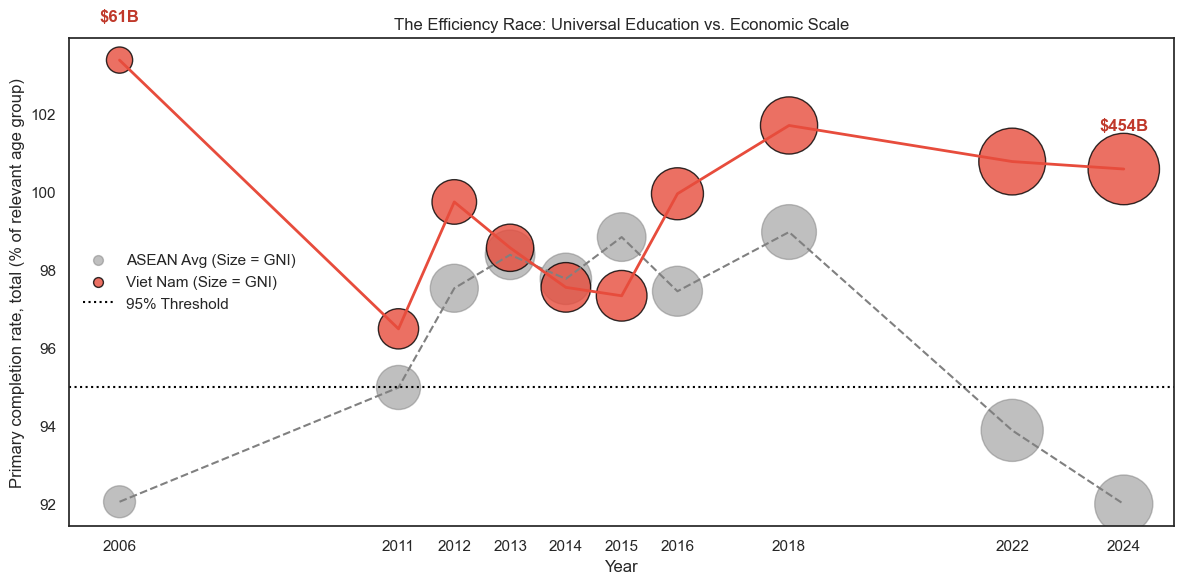

In [51]:
# 1. Define variables and prepare data
c_gni = 'GNI, Atlas method (current US$)'
c_edu = 'Primary completion rate, total (% of relevant age group)'

df_plot = df_final.dropna(subset=[c_gni, c_edu, 'Country Name', 'Year'])
df_vn = df_plot[df_plot['Country Name'] == 'Viet Nam'].sort_values('Year')

# Calculate ASEAN average
df_avg = df_plot[df_plot['Country Name'] != 'Viet Nam'].groupby('Year')[[c_gni, c_edu]].mean().reset_index()

# Filter ASEAN: Only calculate the average for years where Vietnam has reported data
df_avg = df_avg[df_avg['Year'].isin(df_vn['Year'])]

# 2. Plot the chart
fig, ax = plt.subplots(figsize=(12, 6))
sns.set_style("whitegrid")
scale = df_avg[c_gni].max() / 2000 

# ASEAN Trajectory (Synchronized years)
ax.plot(df_avg['Year'], df_avg[c_edu], color='gray', ls='--')
ax.scatter(df_avg['Year'], df_avg[c_edu], s=df_avg[c_gni]/scale, color='gray', alpha=0.5, label='ASEAN Avg (Size = GNI)')

# Viet Nam Trajectory
ax.plot(df_vn['Year'], df_vn[c_edu], color='#E74C3C', lw=2)
ax.scatter(df_vn['Year'], df_vn[c_edu], s=df_vn[c_gni]/scale, color='#E74C3C', alpha=0.8, edgecolor='black', label='Viet Nam (Size = GNI)')

# Add GNI labels for the first and last years
for i in [0, -1]:
    ax.text(df_vn['Year'].iloc[i], df_vn[c_edu].iloc[i] + 1, 
            f"${df_vn[c_gni].iloc[i]*1e-9:.0f}B", color='#C0392B', fontweight='bold', ha='center')

# 3. Axis formatting
ax.axhline(95, color='black', ls=':', label='95% Threshold')
ax.set(title="The Efficiency Race: Universal Education vs. Economic Scale", xlabel="Year", ylabel=c_edu)

# Force X-axis to display exactly Vietnam's years (No extra ticks)
ax.set_xticks(df_vn['Year'].astype(int))

# Fix oversized bubbles in the legend
lgnd = ax.legend(loc='center left')
for handle in lgnd.legend_handles:
    if hasattr(handle, 'set_sizes'):
        handle.set_sizes([50]) 

plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. Baseline Comparison (2006):**
* **Vietnam**: In 2006, with a minimal economic scale (GNI $\approx \$61B$), Vietnam had already achieved a primary completion rate exceeding $100\%$.
* **ASEAN Average**: During the same period, the regional average remained below the $95\%$ universal education threshold, despite a larger collective economic footprint.

**2. Efficiency and Scaling (2006–2024):**
* **The Size-to-Outcome Gap**: Throughout the 18-year trajectory, Vietnam’s data points (red bubbles) consistently occupy a higher position on the Y-axis than the ASEAN average (gray bubbles).

* **Resource Efficiency:** Vietnam reached and sustained elite educational outcomes while its "economic bubble" remained significantly smaller than the regional average for the majority of the timeline.

**3. Recent Divergence (2022–2024):**
* **Vietnam’s Stability**: As of 2024, Vietnam’s economy has scaled to $\$454B$ while maintaining a stable completion rate above $100\%$.
* **ASEAN Decline**: In contrast, the regional average has shown a recent downward trend, falling below the $95\%$ threshold by 2024.

**Conclusion:** The data confirms that a massive Gross National Income is not a prerequisite for high primary education completion. The observed trajectory proves that Vietnam achieved elite-tier educational results early in its development and has maintained them with a significantly smaller absolute economic scale compared to the regional average.

## 3.4 Energy & Environment Ecology
### **Objective 1: Is the rising energy demand in Viet Nam and ASEAN driving their economies into a high-carbon "Red Zone"?**
**Chart Selection & Rationale:**

* **What:** An **Environmental Trade-off Matrix (Quadrant Chart)**.
* **Why:** This format is chosen for its powerful evaluative capabilities. It moves beyond simple correlation and actively assesses *performance*.
    * **Categorical Insight:** By dividing the plot into four distinct quadrants based on overall data averages, the chart instantly classifies development states (e.g., sustainable vs. hazardous).
    * **Highlighting the "Red Zone":** The top-right quadrant represents the worst-case scenario: consuming massive amounts of energy while maintaining highly polluting technologies. This visual framing forces the viewer to confront the "Environmental Penalty" directly.
    * **Immediate Benchmarking:** Plotting Viet Nam and the ASEAN Average on the same grid provides a stark, undeniable contrast in their current developmental positioning and environmental costs.
* **How:** 
    * **Axes Setup:** `Energy Use` drives the X-axis, while `Carbon Intensity` drives the Y-axis.
    * **Thresholds:** The matrix is divided by dashed lines representing the mean values of both metrics across the entire dataset, creating objective mathematical baselines.
    * **Visual Layering:** The top-right quadrant is explicitly shaded as the "Red Zone," and bubble sizes represent the relative impact, making the environmental danger visually intuitive.

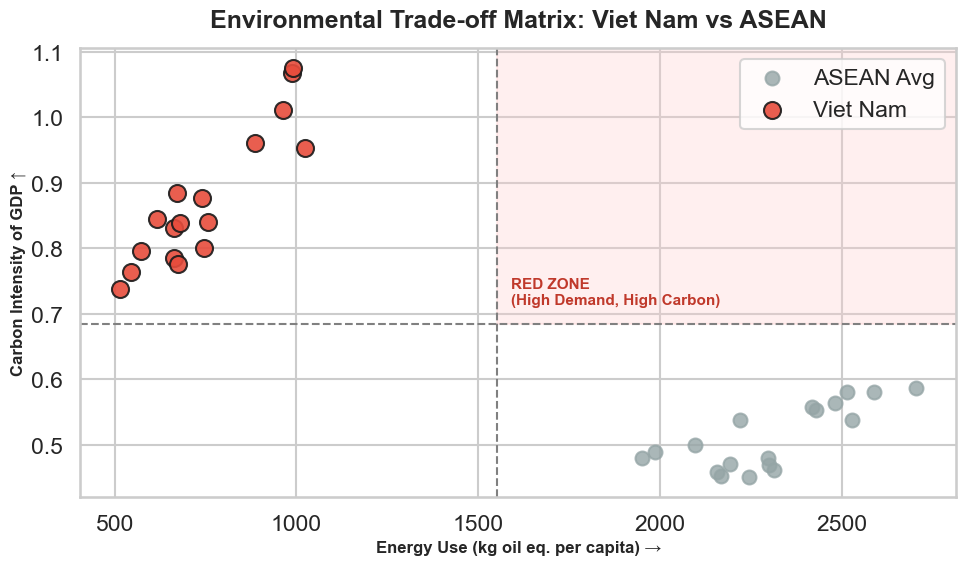

In [52]:
# 1. Define variables and prepare data
c_nrg = 'Energy use (kg of oil equivalent per capita)'
c_co2 = 'Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)'

# Filter data and remove missing values
df_vn = df_final[df_final['Country Name'] == 'Viet Nam'].dropna(subset=[c_nrg, c_co2])
df_asean = df_final[df_final['Country Name'] != 'Viet Nam'].groupby('Year')[[c_nrg, c_co2]].mean().reset_index()

# Calculate central coordinates (thresholds) based on the overall average
x_mid = pd.concat([df_vn[c_nrg], df_asean[c_nrg]]).mean()
y_mid = pd.concat([df_vn[c_co2], df_asean[c_co2]]).mean()

# 2. Initialize plot (whitegrid theme automatically adds gridlines)
sns.set_theme(style="whitegrid", context="talk") 
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Plot scatter points
ax.scatter(df_asean[c_nrg], df_asean[c_co2], s=100, color='#95a5a6', alpha=0.8, label='ASEAN Avg')
ax.scatter(df_vn[c_nrg], df_vn[c_co2], s=150, color='#e74c3c', alpha=0.9, edgecolor='k', label='Viet Nam')

# 4. Draw quadrant axes and shade the Red Zone
xlim, ylim = ax.get_xlim(), ax.get_ylim() # Get exact plot limits after drawing data

ax.axhline(y_mid, color='gray', ls='--', lw=1.5) # Horizontal threshold
ax.axvline(x_mid, color='gray', ls='--', lw=1.5) # Vertical threshold

# Shade the top-right quadrant (Red Zone) tightly
ax.fill_between([x_mid, xlim[1]], y_mid, ylim[1], color='#ffcccc', alpha=0.3)
ax.set(xlim=xlim, ylim=ylim) # Lock limits to prevent shading from expanding the plot

# 5. Add text annotations and format labels
ax.text(x_mid + 40, y_mid + 0.03, 'RED ZONE\n(High Demand, High Carbon)', color='#c0392b', fontweight='bold', fontsize=11)
ax.set_title("Environmental Trade-off Matrix: Viet Nam vs ASEAN", fontweight='bold', pad=15)
ax.set_xlabel("Energy Use (kg oil eq. per capita) →", fontweight='bold', fontsize=12)
ax.set_ylabel("Carbon Intensity of GDP ↑", fontweight='bold', fontsize=12)
ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. The Universal Upward Trend:** Both Viet Nam and the ASEAN Average show a positive correlation over time. As these economies grow, energy use increases, inevitably pulling carbon intensity up with it. 

**2. The ASEAN Baseline (Efficient Scaling):** ASEAN data points cluster in the **bottom-right quadrant**. Despite consuming *more* energy per capita (higher demand), their carbon intensity remains *below* average. This indicates a more mature, efficient industrial engine and a cleaner energy mix.

**3. Viet Nam’s "Inefficiency Trap" (Top-Left):** Viet Nam’s trajectory presents a stark contrast, confined entirely to the **top-left quadrant**. Viet Nam consumes *less* energy per capita than the regional average, yet it operates with a drastically *higher* carbon intensity. 

**Conclusion:** Viet Nam is currently caught in an **Inefficiency Trap**. While the broader ASEAN region manages massive energy demands with relatively better carbon efficiency, Viet Nam's economic output exacts a severe environmental penalty. This structural gap highlights a heavy reliance on carbon-intensive fossil fuels and an urgent need for technological upgrades.


### **Objective 2: Does a high economic reliance on coal extraction drive forest depletion when compared to regional trends?**
**Chart Selection & Rationale:**
* **What:** A **Unified Dual-Axis Clustered Bar + Multi-Line Chart**.
* **Why:** This hybrid format is chosen for its superior **benchmarking** capabilities:
    * **Direct Comparison:** Clustered bars (side-by-side) allow for an instant comparison of coal dependency between Viet Nam and ASEAN for every single year.
    * **Trend Divergence:** The dual lines (Forest Area) visually track the "Ecological Race." It clearly shows whether Viet Nam is outperforming the region in reforestation despite its coal-heavy industrial profile.
    * **Scale Integration:** The dual-axis setup allows us to overlay economic percentages (% of GDP) with ecological percentages (% of land) without distorting the visual narrative.
* **How:** 
    * **Bars (Primary Axis):** Represent Coal Rents for both entities.
    * **Lines (Secondary Axis):** Represent Forest Area percentages.
    * **Unified Scale:** Synchronized axes ensure that the comparison remains mathematically rigorous and visually intuitive.

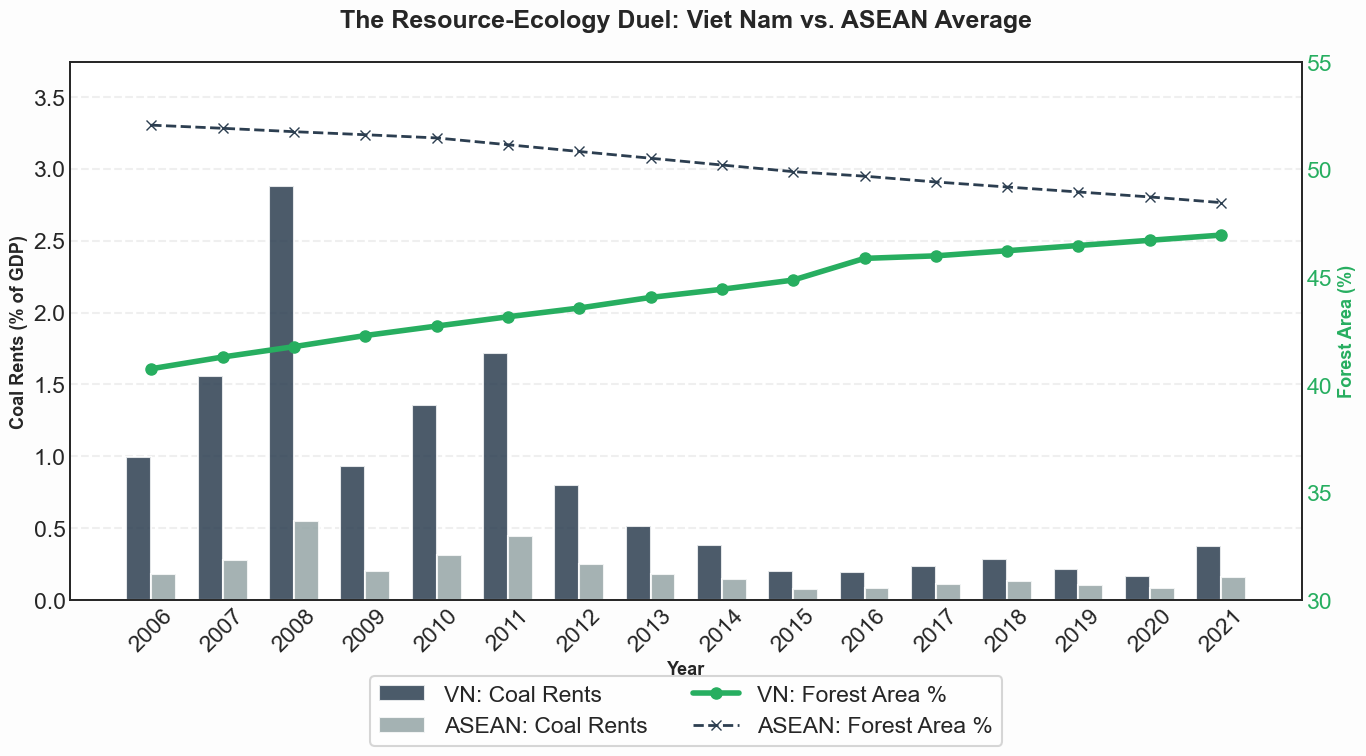

In [53]:
# 1. Define Variables & Prepare Data
c_coal = 'Coal rents (% of GDP)'
c_forest = 'Forest area (% of land area)'

# Extract Viet Nam data
df_vn = df_final[df_final['Country Name'] == 'Viet Nam'].sort_values('Year').dropna(subset=[c_coal, c_forest])

# Calculate ASEAN average (excluding Viet Nam)
df_asean = df_final[df_final['Country Name'] != 'Viet Nam'].groupby('Year')[[c_coal, c_forest]].mean().reset_index().dropna()

# 2. Setup Plotting Environment
plt.style.use('seaborn-v0_8-white')
fig, ax1 = plt.subplots(figsize=(14, 8), facecolor='#FDFDFD')
ax2 = ax1.twinx() # Secondary axis for Forest Area

years = df_vn['Year'].values
x = np.arange(len(years)) # Label locations
width = 0.35 

# 3. Plot Clustered Bars (Coal Rents Only)
# Viet Nam Bars
ax1.bar(x - width/2, df_vn[c_coal], width, label='VN: Coal Rents', color='#2c3e50', alpha=0.85)

# ASEAN Bars
ax1.bar(x + width/2, df_asean[c_coal], width, label='ASEAN: Coal Rents', color='#95a5a6', alpha=0.85)

# 4. Plot Multi-Line Chart (Forest Area)
ax2.plot(x, df_vn[c_forest], color='#27ae60', marker='o', lw=4, markersize=8, label='VN: Forest Area %')
ax2.plot(x, df_asean[c_forest], color='#2c3e50', marker='x', lw=2, ls='--', markersize=7, label='ASEAN: Forest Area %')

# 5. Formatting & Styling
ax1.set_xlabel('Year', fontweight='bold', fontsize=13)
ax1.set_ylabel('Coal Rents (% of GDP)', fontweight='bold', fontsize=13)
ax2.set_ylabel('Forest Area (%)', fontweight='bold', color='#27ae60', fontsize=13)

ax1.set_xticks(x)
ax1.set_xticklabels(years.astype(int), rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax2.tick_params(axis='y', labelcolor='#27ae60')

# Set limits to fit the data comfortably
ax1.set_ylim(0, max(df_vn[c_coal].max(), df_asean[c_coal].max()) * 1.3) 
ax2.set_ylim(30, 55)

plt.title("The Resource-Ecology Duel: Viet Nam vs. ASEAN Average", fontsize=18, fontweight='bold', pad=25)

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=True)

plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. The Resource Dependency Gap**: Viet Nam consistently shows higher Coal Rents as a % of GDP compared to the ASEAN average. While Viet Nam’s dependency peaked dramatically in 2008 (~2.9%) before stabilizing, its economic reliance on coal extraction has remained structurally higher than the regional baseline throughout the studied period.

**2. The "Great Convergence" of Forest Cover**: A striking divergence exists in ecological health. While the ASEAN Average forest area is in a steady, continuous decline (dropping from 53% to 48%), Viet Nam follows a sustained upward trajectory (rising from 41% to 47%). The initial 12% ecological gap in 2006 has nearly vanished to just 1% by 2021.

**3. Successful Ecological Decoupling**: Viet Nam demonstrates a rare ability to decouple industrial extraction from environmental depletion. Even during the years of peak coal rents (2006–2011), forest cover continued to expand, whereas the regional average shows consistent depletion despite having lower relative coal dependency.

**Conclusion**: Viet Nam acts as a Green Outlier in the region. By reversing the "extraction-depletion" cycle, Viet Nam is transitioning from a resource-dependent economy to one that grows its ecological capital. This marks a successful shift toward a more resilient and sustainable development model.

### **Objective 3: How does freshwater productivity change under the pressure of agricultural expansion?**
**Chart Selection & Rationale**
* **What**: **Dual-Panel Time Series** (Line Charts).
* **Why**: 
    * **Trend Clarity**: Removing the X-Y interaction allows for a focused look at the velocity of change for each variable independently over the years.
    * **Direct Benchmarking**: It provides a crystal-clear "Gap Analysis" between Viet Nam and the ASEAN average, showing if the gap is widening or closing.
    * **Structural Alignment**: This format highlights the "Inverse Symmetry"—visually proving that as the agricultural bar (pressure) drops, the productivity line (efficiency) rises.
    
* **How**: Two subplots share the same X-axis (Year) to ensure perfect chronological alignment between the structural cause and the efficiency effect.


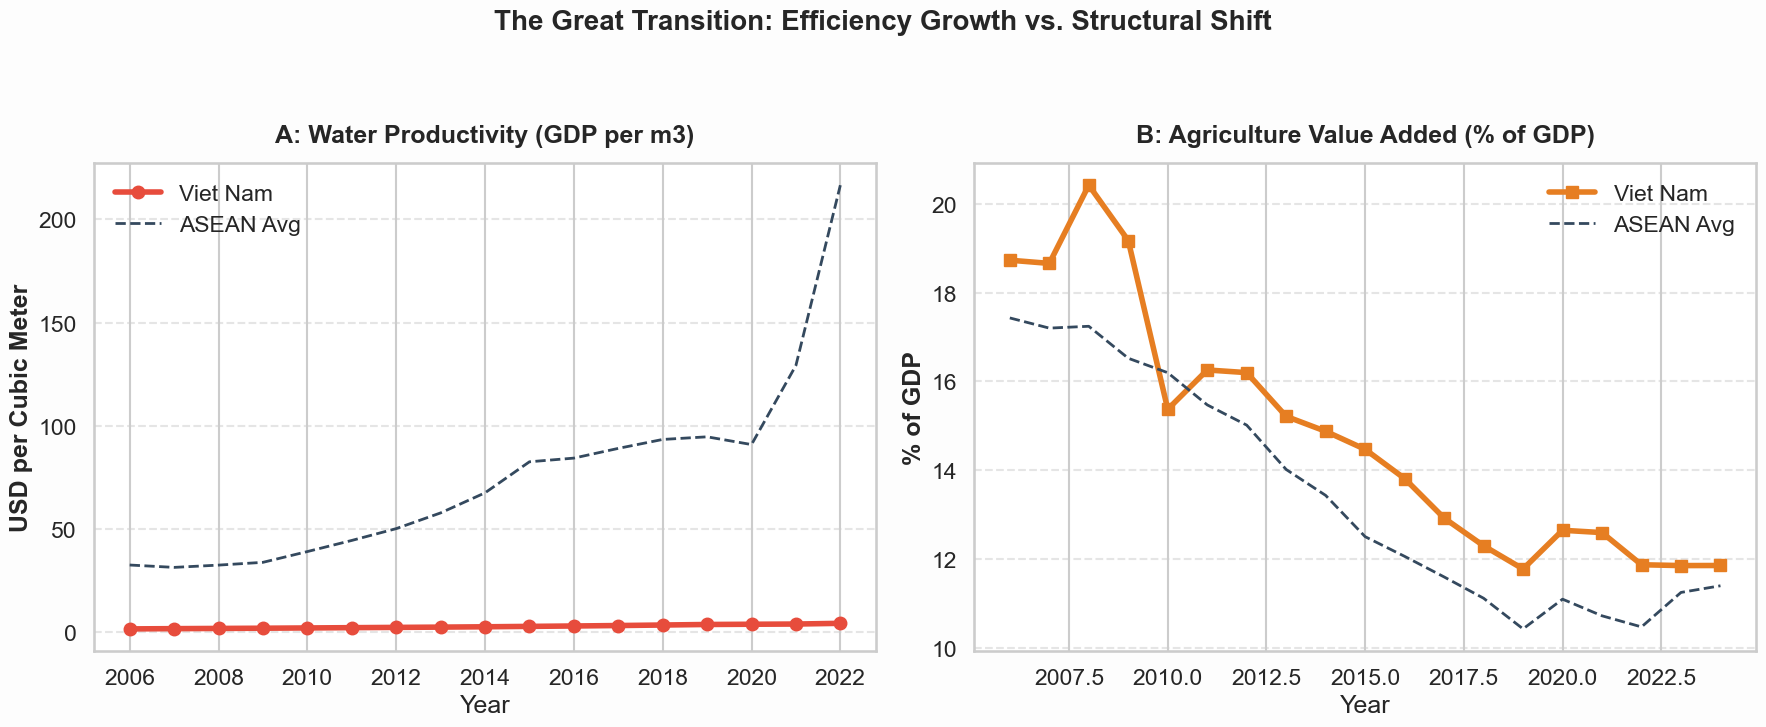

In [54]:
# 1. Prepare Data
c_prod = 'Water productivity, total (constant 2015 US$ GDP per cubic meter of total freshwater withdrawal)'
c_agri = 'Agriculture, forestry, and fishing, value added (% of GDP)'

# Extract Viet Nam and ASEAN Avg
df_vn = df_final[df_final['Country Name'] == 'Viet Nam'].sort_values('Year')
df_asean = df_final[df_final['Country Name'] != 'Viet Nam'].groupby('Year')[[c_prod, c_agri]].mean().reset_index()

# 2. Setup Plotting Environment
sns.set_theme(style="whitegrid", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='#FDFDFD')

# --- Plot 1: Water Productivity (The Efficiency Climb) ---
ax1.plot(df_vn['Year'], df_vn[c_prod], color='#e74c3c', lw=4, marker='o', label='Viet Nam')
ax1.plot(df_asean['Year'], df_asean[c_prod], color='#34495e', lw=2, ls='--', label='ASEAN Avg')
ax1.set_title("A: Water Productivity (GDP per m3)", fontweight='bold', pad=15)
ax1.set_ylabel("USD per Cubic Meter", fontweight='bold')
ax1.legend()

# --- Plot 2: Agriculture Value Added (The Structural Shift) ---
ax2.plot(df_vn['Year'], df_vn[c_agri], color='#e67e22', lw=4, marker='s', label='Viet Nam')
ax2.plot(df_asean['Year'], df_asean[c_agri], color='#34495e', lw=2, ls='--', label='ASEAN Avg')
ax2.set_title("B: Agriculture Value Added (% of GDP)", fontweight='bold', pad=15)
ax2.set_ylabel("% of GDP", fontweight='bold')
ax2.legend()

# 3. Final Polish
for ax in [ax1, ax2]:
    ax.set_xlabel("Year")
    ax.grid(axis='y', ls='--', alpha=0.5)

plt.suptitle("The Great Transition: Efficiency Growth vs. Structural Shift", fontsize=20, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. The Productivity Divergence:**
* **ASEAN Average:** Exhibits an exponential growth pattern, skyrocketing from ~$30/m³ in 2006 to over **$200/m³ by 2022**. This indicates a massive leap in regional water-use efficiency.
* **Viet Nam:** Shows a stagnant, near-flatline trajectory at a low level (<$10/m³). Despite overall GDP growth, the economic value extracted per unit of freshwater has not significantly improved over 16 years.

**2. The Structural Convergence:**
* Both entities show a decisive downward trend in agricultural dependency. 
* **Viet Nam** has undergone a more aggressive transformation, dropping from a peak of **~20.5% (2008)** to **~12% (2022)**, successfully aligning itself with the regional average of ~11.5%.

**3. The Asymmetric Transition:**
* The data reveals a significant paradox: Viet Nam has successfully mirrored the **economic structure** of the region (reducing agri-dependency) but has failed to mirror the **resource efficiency** (failing to increase water productivity).

**Conclusion**
Viet Nam has achieved **Structural Modernization** but faces a **Technology Gap**. While the country has successfully transitioned its sectors to match the regional norm, it has yet to convert its water resources into high economic value. Moving forward, the focus must shift from changing what is produced to how efficiently it is produced.

## 3.5 Population, Urbanization & Social Security
### **Objective 1: How does rapid urbanization impact national efforts to eradicate poverty?**
**Chart Selection & Rationale:**

* **What:** A **Dual-Panel Slope Graph** comparing two core milestones (2006 vs. 2022).
* **Why:** This is the most visually powerful and refined tool for long-term analysis because:
    * **Signal over Noise:** By hiding the data from the intervening years, the chart filters out short-term fluctuations, forcing the viewer to focus directly on the overall magnitude and "velocity" of change over the 16-year period (The "Before and After").
    * **Visualizing the "Scissors Effect":** Placing the two panels side-by-side perfectly illustrates the inverse correlation: the steep upward slope of Urbanization (Panel A) directly resonates with the steep downward slope of Poverty (Panel B).
    * **High-Contrast Benchmarking:** By observing the steepness of the connecting lines, the audience can instantly compare the intensity of Viet Nam's breakthrough against the steady trajectory of the ASEAN regional average.
* **How:** The chart employs a minimalist design paradigm—removing all gridlines and the Y-axis, utilizing only vertical anchor lines at the two time milestones to maximally highlight the slope of the developmental path.

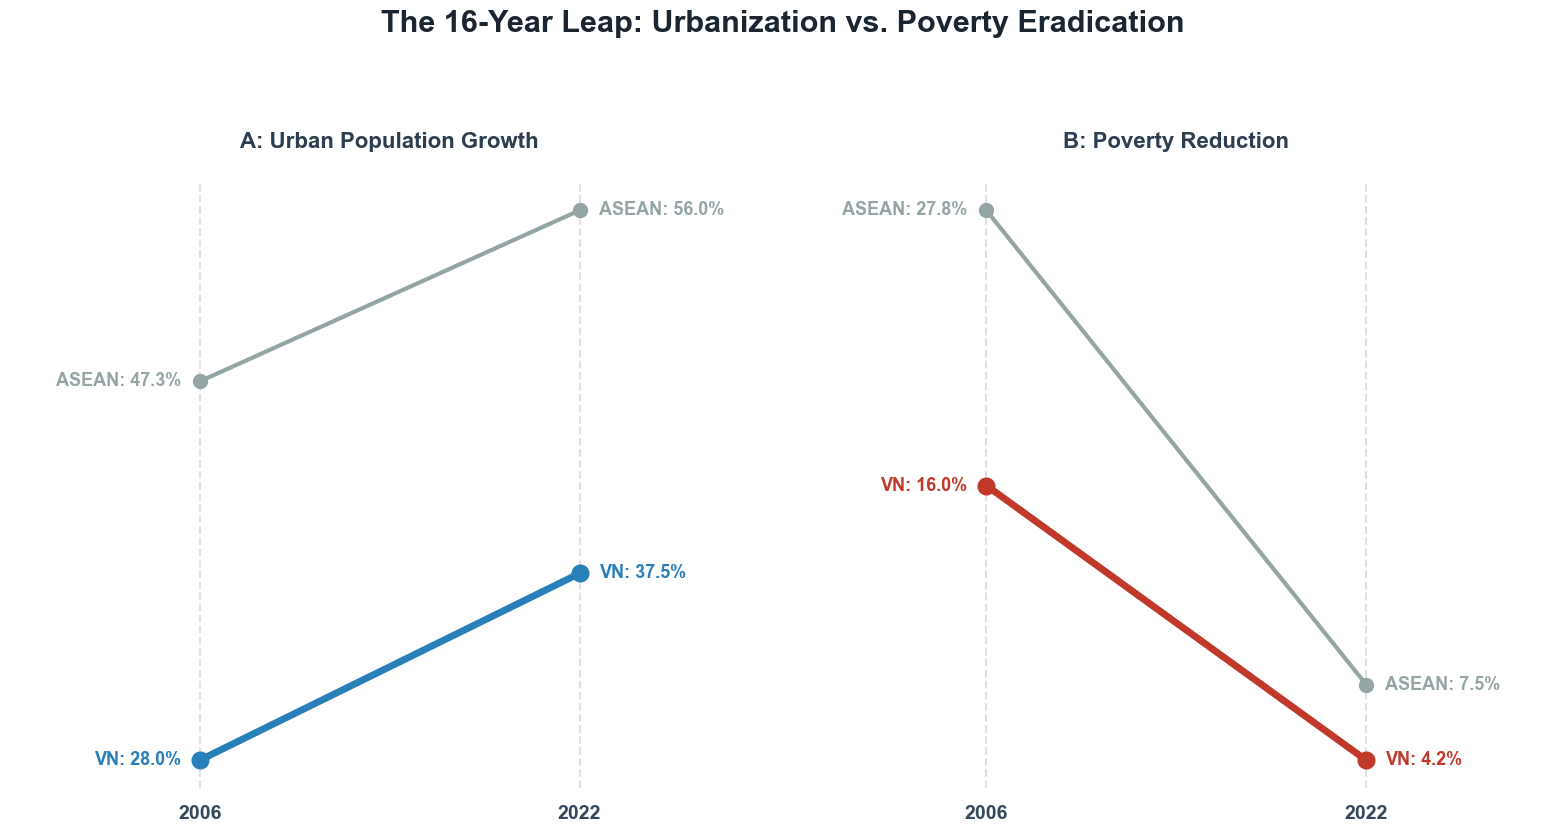

In [55]:
# 1. Prepare Data
c_urban = 'Urban population (% of total population)'
c_poverty = 'Poverty headcount ratio at national poverty lines (% of population)'
years = [2006, 2022] # Using 2022 as the latest available benchmark

def get_slope_data(country):
    if country == 'ASEAN':
        df = df_final[df_final['Country Name'] != 'Viet Nam'].groupby('Year')[[c_urban, c_poverty]].mean().reset_index()
    else:
        df = df_final[df_final['Country Name'] == country]
    return df[df['Year'].isin(years)].sort_values('Year')

vn_slope = get_slope_data('Viet Nam')
asean_slope = get_slope_data('ASEAN')

# 2. Setup Figure & Aesthetic Theme
sns.set_theme(style="white", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), facecolor='#FFFFFF')

def draw_beautiful_slope(ax, df_vn, df_asean, column, title, color_vn, color_asean):
    # Anchor lines (Vertical dashed lines for the years)
    ax.axvline(0, color='#e0e0e0', lw=1.5, ls='--', zorder=1)
    ax.axvline(1, color='#e0e0e0', lw=1.5, ls='--', zorder=1)
    
    # Extract values
    vn_start, vn_end = df_vn[column].iloc[0], df_vn[column].iloc[-1]
    as_start, as_end = df_asean[column].iloc[0], df_asean[column].iloc[-1]

    # Plot Lines & Markers
    ax.plot([0, 1], [as_start, as_end], marker='o', markersize=10, lw=3, color=color_asean, label='ASEAN Avg', zorder=3)
    ax.plot([0, 1], [vn_start, vn_end], marker='o', markersize=12, lw=5, color=color_vn, label='Viet Nam', zorder=4)
    
    # Annotations (Left Side - 2006)
    ax.text(-0.05, vn_start, f"VN: {vn_start:.1f}%", ha='right', va='center', fontweight='bold', color=color_vn, fontsize=13)
    ax.text(-0.05, as_start, f"ASEAN: {as_start:.1f}%", ha='right', va='center', fontweight='bold', color=color_asean, fontsize=13)
    
    # Annotations (Right Side - 2022)
    ax.text(1.05, vn_end, f"VN: {vn_end:.1f}%", ha='left', va='center', fontweight='bold', color=color_vn, fontsize=13)
    ax.text(1.05, as_end, f"ASEAN: {as_end:.1f}%", ha='left', va='center', fontweight='bold', color=color_asean, fontsize=13)

    # Styling Axes
    ax.set_title(title, fontweight='bold', fontsize=16, pad=25, color='#2c3e50')
    ax.set_xlim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['2006', '2022'], fontweight='bold', fontsize=14, color='#34495e')
    
    # Minimalist cleanup: remove all borders and Y-axis
    for spine in ['top', 'right', 'left', 'bottom']: 
        ax.spines[spine].set_visible(False)
    ax.get_yaxis().set_visible(False)

# 3. Draw the Slopes
# Panel A: Urbanization (Blue vs Grey)
draw_beautiful_slope(ax1, vn_slope, asean_slope, c_urban, "A: Urban Population Growth", '#2980b9', '#95a5a6')

# Panel B: Poverty (Red vs Grey)
draw_beautiful_slope(ax2, vn_slope, asean_slope, c_poverty, "B: Poverty Reduction", '#c0392b', '#95a5a6')

# 4. Final Polish
plt.suptitle("The 16-Year Leap: Urbanization vs. Poverty Eradication", fontsize=22, fontweight='bold', color='#1a252f', y=1.05)
plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. Steady Urban Expansion (Panel A):**
The slope graph reveals a consistent demographic shift in Viet Nam. Starting from a highly rural base of **28.0%** in 2006, Viet Nam’s urban population grew to **37.5%** by 2022. While Viet Nam still operates below the ASEAN urbanization average (which grew from 47.3% to 56.0%), its upward trajectory shows a steady and deliberate pace of structural modernization.

**2. Striking Poverty Eradication (Panel B):**
Panel B highlights an overwhelming success in social welfare. Viet Nam started from a much stronger baseline than the region in 2006 (**16.0%** vs. ASEAN's 27.8%) and successfully drove its national poverty rate down to a remarkable **4.2%**. Although ASEAN experienced a steeper absolute drop due to its high starting point, Viet Nam maintained its welfare advantage, ending the period significantly below the regional average of 7.5%.

**Conclusion:**
When viewed together, the "Scissors Effect" is undeniable. For Viet Nam, an almost 10-percentage-point increase in urbanization corresponds directly with crushing the poverty rate down to single digits. This confirms the inverse correlation: as the population structurally shifts to urban centers, poverty systematically declines.

### **Objective 2: How does Viet Nam's macroeconomic stability compare to the regional ASEAN average?**
**Chart Selection & Rationale**
* **What:** **Comparative Line Chart with Baseline Shading.**
* **Why:** * **Clear Benchmarking:** The ASEAN average is plotted as a dashed line with a shaded background, creating a visual "Normal Zone" for the region. 
    * **Highlighting Volatility:** Viet Nam's trajectory is overlaid as a bold, solid line. Extreme deviations (such as the spikes >10% in 2008 and 2011) that pierce through the regional shaded area instantly highlight a localized macroeconomic shock.
    * **Trend Tracking:** A line chart is the optimal choice for time-series data, allowing the audience to seamlessly track Viet Nam's historical journey from extreme volatility to post-2014 macroeconomic stabilization.
* **How:** 
    * **X-Axis (Horizontal):** Represents the **Time-series (Years)** from 2006 to 2022, allowing for a continuous tracking of economic cycles.
    * **Y-Axis (Vertical):** Represents the **Consumer Inflation Rate (Annual %)**. A higher position on this axis indicates a more severe erosion of purchasing power.
    * **The "Danger Zone" Reference:** A horizontal dashed line is set at the **10% threshold** to separate "Moderate Inflation" (one-digit) from "Galloping Inflation" (two-digits).

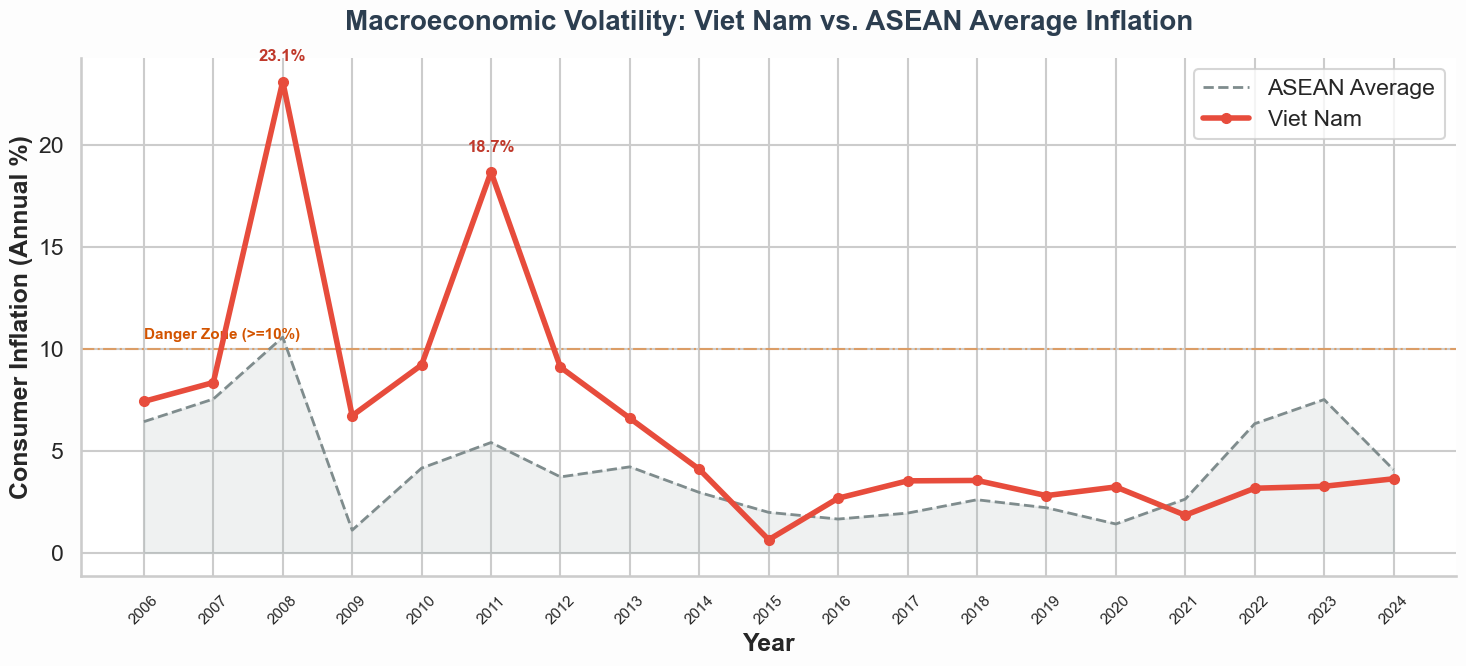

In [56]:
# 1. Prepare Data
c_inf = 'Inflation, consumer prices (annual %)'

# Keep all years with inflation data (Remove empty rows)
df_inf = df_final.dropna(subset=[c_inf]).copy()

# Get Viet Nam data and calculate ASEAN average
df_vn = df_inf[df_inf['Country Name'] == 'Viet Nam'].sort_values('Year')
df_asean = df_inf[df_inf['Country Name'] != 'Viet Nam'].groupby('Year')[c_inf].mean().reset_index()

# Get a list of all years for the X-axis
all_years = sorted(df_inf['Year'].unique())

# 2. Setup Figure
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(15, 7), facecolor='#FDFDFD')

# --- Plot ASEAN Average (Grey dashed line) ---
plt.plot(df_asean['Year'], df_asean[c_inf], color='#7f8c8d', lw=2, ls='--', label='ASEAN Average')
# Fill the area under the ASEAN line
plt.fill_between(df_asean['Year'], df_asean[c_inf], color='#95a5a6', alpha=0.15)

# --- Plot Viet Nam (Red solid line) ---
plt.plot(df_vn['Year'], df_vn[c_inf], color='#e74c3c', lw=4, marker='o', markersize=7, zorder=5, label='Viet Nam')

# 3. Highlight Viet Nam's inflation peaks (>10%)
extreme_years = df_vn[df_vn[c_inf] >= 10]
for _, row in extreme_years.iterrows():
    # Add text label above the peaks
    plt.text(row['Year'], row[c_inf] + 1, f"{row[c_inf]:.1f}%", 
             color='#c0392b', fontweight='bold', ha='center', fontsize=12, zorder=6)

# 4. Formatting the chart
plt.title("Macroeconomic Volatility: Viet Nam vs. ASEAN Average Inflation", fontsize=20, fontweight='bold', pad=20, color='#2c3e50')
plt.ylabel("Consumer Inflation (Annual %)", fontweight='bold')
plt.xlabel("Year", fontweight='bold')

# Show all years on X-axis and rotate 45 degrees
plt.xticks(all_years, rotation=45, fontsize=11)

# Draw the 10% Danger Zone line
plt.axhline(10, color='#e67e22', ls='-.', lw=1.5, alpha=0.6, zorder=1)
plt.text(all_years[0], 10.5, 'Danger Zone (>=10%)', color='#d35400', fontsize=11, fontweight='bold')

# Remove top and right borders for a cleaner look
sns.despine()

# Show legend
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. Volatility Gap in Early Years (2006–2012):**
The line chart highlights a clear divergence between Viet Nam and the ASEAN average during the early period. Viet Nam experienced extreme inflation spikes, peaking at **23.1% in 2008** and **18.7% in 2011**, far exceeding the regional average, which remained below 10%. This indicates a period of significant macroeconomic instability, where Viet Nam was far more vulnerable to external and internal shocks compared to its regional peers.

**2. Rapid Stabilization and Convergence (2012–2020):**
Following 2012, Viet Nam underwent a sharp and sustained stabilization process. Inflation dropped dramatically, reaching a low of **0.6% in 2015**, and then stabilized within the **2–4% range**, closely aligning with ASEAN levels. During this phase, the gap between Viet Nam and the regional average narrowed significantly, signaling improved macroeconomic management and policy effectiveness.

**3. Relative Stability in Recent Years (2021–2024):**
In the most recent period, the trend reverses slightly in favor of Viet Nam. While ASEAN experienced renewed inflationary pressure—particularly in **2022–2023**—Viet Nam maintained relatively stable and moderate inflation levels. This suggests stronger resilience and more effective inflation control mechanisms compared to the broader region.

**Conclusion:**
Vietnam has transitioned from a highly volatile inflation environment to a more stable regime, gradually converging with—and in recent years, matching or outperforming—the ASEAN average.

### **Objective 3: How crucial are personal remittances to the economies of labor-exporting countries?**
**Chart Selection & Rationale**
* **What:** **Multivariate Bubble Plot (GDP vs. Dependency % vs. Total Volume).**
* **Why:** 
    * **Multi-dimensional Context:** It allows us to see three variables at once: Scale (X), Dependency (Y), and Magnitude (Size).
    * **Handling Extremes:** Using a logarithmic scale for GDP allows us to compare massive economies like Indonesia with smaller ones like Brunei on the same chart without distortion.
    * **Identifying Groups:** It clearly categorizes countries into "Labor Export Hubs" (High Y), "Balanced Engines" (Large Size), and "Domestic-Led Economies" (Low Y).
* **How:** 
    * **X-Axis (Horizontal):** Represents **GDP (Current US$) on a Logarithmic scale**, showing the total economic power of each country.
    * **Y-Axis (Vertical):** Represents **Personal Remittances received (% of GDP)**, measuring the level of economic dependency.
    * **Bubble Size:** Represents the **Total Remittance Volume in Billion USD**, showing the actual "cash flow" entering the country.
    * **Color Highlight:** **Viet Nam** is color-coded in red to distinguish its position from other ASEAN peers (in grey).

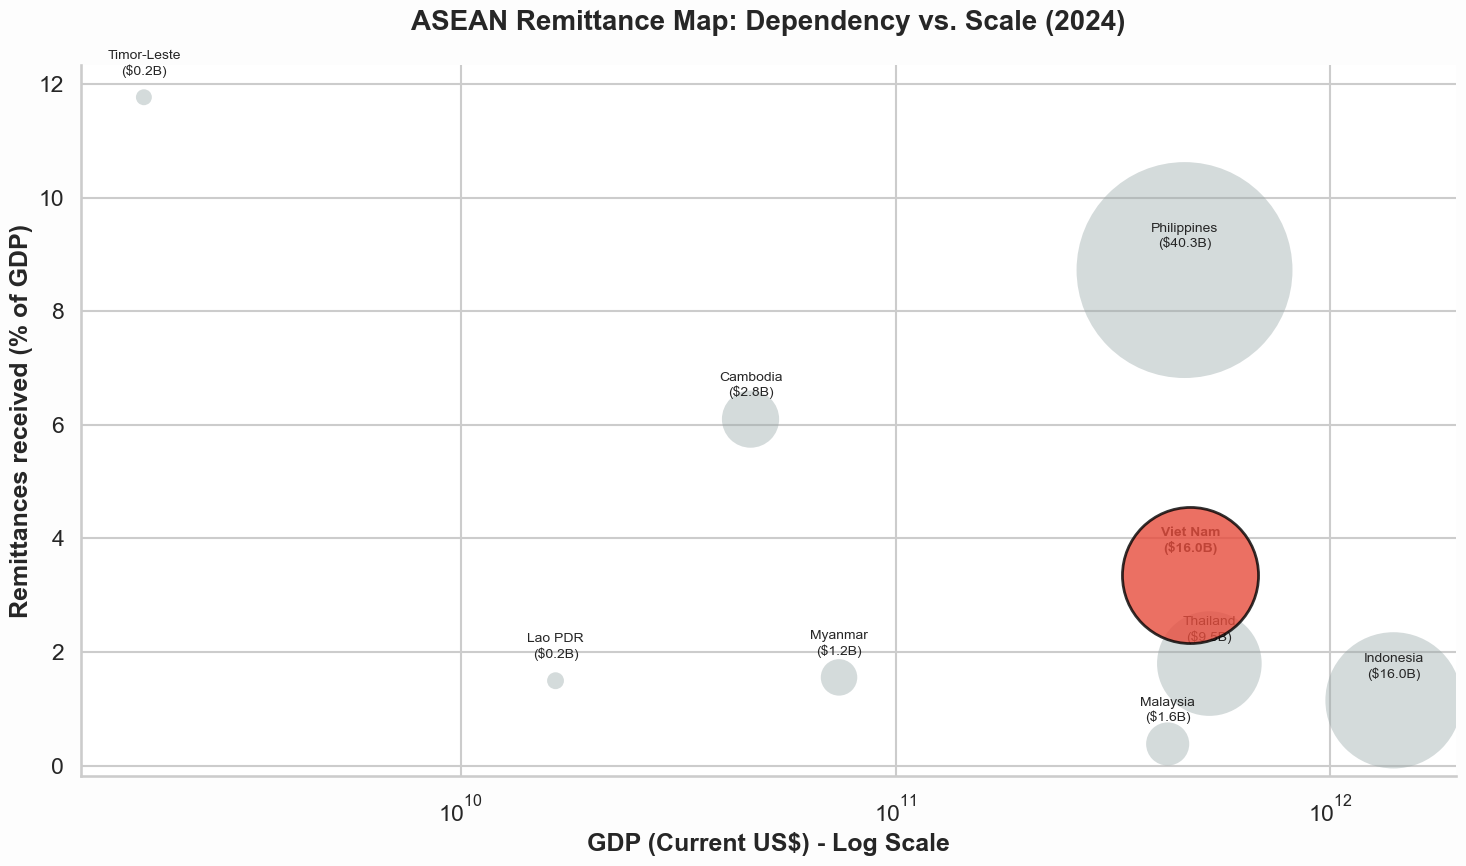

In [57]:
# 1. Data Preparation
c_rem = 'Personal remittances, received (% of GDP)'
c_gdp = 'GDP (current US$)'

# Find the latest year with data for the whole region
df_temp = df_final.dropna(subset=[c_rem, c_gdp])
target_year = df_temp['Year'].max()
df_3 = df_temp[df_temp['Year'] == target_year].copy()

# Feature Engineering: Calculate absolute Remittance in Billion USD
df_3['Remittance_Billion'] = (df_3[c_gdp] * (df_3[c_rem] / 100)) / 1e9

# 2. Setup Figure
sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(15, 9), facecolor='#FDFDFD')

# 3. Create Bubble Plot
for i in range(len(df_3)):
    country = df_3.iloc[i]['Country Name']
    is_vn = (country == 'Viet Nam')
    
    plt.scatter(
        df_3.iloc[i][c_gdp], 
        df_3.iloc[i][c_rem],
        s=df_3.iloc[i]['Remittance_Billion'] * 600, # Adjust scale for visibility
        alpha=0.8 if is_vn else 0.4,
        color='#e74c3c' if is_vn else '#95a5a6',
        edgecolor='black' if is_vn else 'none',
        linewidth=2 if is_vn else 0,
        zorder=5 if is_vn else 2
    )
    
    # Annotate country names
    plt.text(
        df_3.iloc[i][c_gdp], 
        df_3.iloc[i][c_rem] + 0.4, 
        f"{country}\n(${df_3.iloc[i]['Remittance_Billion']:.1f}B)", 
        ha='center', fontsize=10, fontweight='bold' if is_vn else 'normal'
    )

# 4. Final Polish
plt.xscale('log') # Use Log Scale to see all countries clearly
plt.title(f"ASEAN Remittance Map: Dependency vs. Scale ({int(target_year)})", fontsize=20, fontweight='bold', pad=25)
plt.xlabel("GDP (Current US$) - Log Scale", fontweight='bold')
plt.ylabel("Remittances received (% of GDP)", fontweight='bold')


sns.despine()
plt.tight_layout()
plt.show()

**Analysis & Conclusion**

**1. The Extremes of Dependency**
* **Timor-Leste**: Represents the highest structural dependency in the region (~12% of GDP). However, its **tiny bubble size ($0.2B)** indicates that while these inflows are critical for their local economy, they have minimal impact on the regional financial scale.
* **Philippines**: Remains the undisputed "Remittance King." With nearly **9% of its GDP** coming from abroad and **a massive $40.3 Billion USD** inflow (the largest bubble), the Philippines showcases an economy structurally built around labor exports.

**2. Viet Nam’s Strategic Sweet Spot**
* **The Scale of Inflow**: While its dependency ratio is moderate (~3.5% of GDP), the absolute value is a staggering **$16.0 Billion USD**.
* **Efficiency vs. Dependency**: A key insight arises when comparing **Viet Nam** to **Indonesia**. Both receive exactly **$16.0B** in cash, yet Viet Nam is positioned much higher on the Y-axis. This proves that $16B carries far more weight and strategic importance for Viet Nam's macroeconomic stability than it does for the trillion-dollar Indonesian economy.

**Conclusion**:
Viet Nam’s $16B annual remittance inflow acts as a critical financial buffer, providing stable hard currency to support the national economy and domestic consumption. By maintaining high-impact inflows without falling into risky hyper-dependency, Viet Nam effectively leverages its overseas human capital as a strategic, resilient engine for long-term macroeconomic stability.

# 4. Conclusion

## 4.1 Macroeconomics & Trade
Over the analyzed period, Viet Nam's macroeconomic and trade landscape has undergone a profound structural transformation, evolving from a capital-absorbing developing nation into a highly integrated, high-value regional powerhouse. The data synthesizes three core economic achievements:

* **Unprecedented Resilience & Scaling (The Foundation):** Viet Nam has consistently demonstrated exceptional economic resilience against global shocks. By avoiding the ASEAN-wide recession during the 2020 COVID-19 pandemic and maintaining positive growth, the country has driven a powerful "Catch-up Effect," significantly closing the GDP scale gap with its regional peers.
* **Hyper-Globalized Trade Engine (The Catalyst):** The nation has achieved explosive trade openness, with total trade volume soaring past 170% of its GDP—leaving the ASEAN average far behind. By shifting the structural balance slightly toward exports, Viet Nam has successfully cemented its status as a highly active, export-driven manufacturing hub.
* **Ascension in the Global Value Chain (The Upgrade):** Most importantly, Viet Nam has proven its ability to effectively digest foreign capital. The historical data shows a successful transition from merely absorbing FDI to translating it into exponential high-tech output. With high-tech exports now stabilized at 40-45% of total exports, the economy has fundamentally upgraded its structural quality.

## 4.2 Health & Public Health
An in-depth analysis of Viet Nam’s health indicators over the past two decades reveals a highly resilient and deeply entrenched public health system. The country has successfully decoupled continuous health improvements from the need for massive budget expansions, demonstrating exceptional systemic efficiency. The data synthesizes three core strategic achievements and one critical challenge:

* **High-ROI Health Optimization (The Efficiency Engine):** Viet Nam has achieved remarkable long-term improvements in core health outcomes—such as the continuous, unbroken decline in under-5 mortality—without inflating its health expenditure as a percentage of GDP. This proves a high Return on Investment (ROI) and highlights the strength of its primary and preventive healthcare networks over mere financial input.
* **Systemic Resilience & The "Accumulated Shield" (The Defense Mechanism):** The robust inverse correlation between DPT immunization and infant mortality underscores a powerful "vaccine shield." Notably, even when faced with a severe immunization supply chain disruption in 2023, the infant mortality rate continued to drop to historic lows. This confirms that years of sustained high coverage have built a deep, accumulated immunity and a resilient primary care foundation capable of withstanding short-term volatility.
* **Macro-Demographic Maturity vs. Micro-Vulnerability (The Strategic Shift):** Viet Nam achieved total fertility stability (reaching replacement levels) nearly two decades ahead of the ASEAN average, anchoring its macro-demographic transition. However, a critical anomaly exists: adolescent fertility. Despite high overall contraceptive prevalence (>70%), the adolescent birth rate spiked and currently remains above the regional benchmark.

## 4.3 Education & Innovation
An integrated analysis of Viet Nam’s education, digital infrastructure, and R&D landscape reveals a nation at a critical developmental crossroads. While Viet Nam has mastered the foundational elements of human capital, it faces significant structural bottlenecks in transitioning to a high-value knowledge economy. The data synthesizes three defining characteristics of this transition:

* **The Fundamental Triumph (High Resource Efficiency):** Viet Nam is a regional outlier in foundational human capital. By achieving elite-tier primary education completion rates early on—despite having a fraction of the ASEAN average Gross National Income—Viet Nam proved that systemic efficiency and policy prioritization can triumph over raw economic scale.
* **The Conversion Bottleneck (Digital vs. Advanced Education):** Despite rapidly building a hyper-connected society with mobile penetration rivaling regional peers, Viet Nam underperforms in converting this digital leverage into advanced human capital. The lag in tertiary enrollment indicates that physical infrastructure alone is insufficient without the socioeconomic catalysts needed to drive higher education.
* **The Structural Innovation Deficit (R&D and Services):** The transition toward a service-driven, knowledge-based economy remains sluggish. With R&D expenditure consistently trailing the ASEAN average (0.4% vs. 0.6-0.9%), Viet Nam’s service sector value added naturally plateaus at a lower tier (~41.5% vs. ASEAN’s ~50%). Incremental growth is proving inadequate to close this structural gap.

## 4.4 Energy & Environment Ecology
An integrated analysis of Viet Nam’s energy consumption, resource extraction, and ecological footprint reveals a deeply paradoxical trajectory of sustainable development. While Viet Nam demonstrates exceptional capabilities in ecological conservation and structural modernization, it is currently constrained by severe technological inefficiencies. The data synthesizes this complex transition into three distinct characteristics:

* **The Ecological Triumph (The "Green Outlier"):** Viet Nam has achieved a remarkable feat in ecological management. By successfully decoupling its historical reliance on coal extraction from forest depletion, the nation reversed the "extraction-depletion" cycle. While the ASEAN average suffers from continuous deforestation, Viet Nam is actively expanding its ecological capital, proving that resource dependency does not strictly mandate environmental degradation.
* **The Asymmetric Transition (Structure vs. Efficiency):** Viet Nam has successfully mirrored the regional benchmark in structural modernization by decisively reducing its agricultural dependency. However, this structural shift exposes a severe "Technology Gap." Despite transitioning away from agriculture, Viet Nam has failed to elevate its freshwater productivity, remaining stagnant while the ASEAN average experiences exponential leaps in water-use efficiency. 
* **The Industrial Inefficiency Trap (The "Red Zone"):** The most critical vulnerability lies in Viet Nam's energy matrix. Operating entirely within the high-carbon quadrant, Viet Nam consumes less energy per capita than its regional peers but exacts a disproportionately higher environmental penalty. This confirms a heavy reliance on carbon-intensive fossil fuels and a lack of optimized, clean industrial engines.